# Assignment 3: Retrieval-Augmented Generation (RAG) Design

**Student ID:** a1960831
**Course:** Advanced Topics in Artificial Intelligence and Machine Learning
**Topic:** A Guide to Generating RAGs for Cybersecurity Professionals

This notebook implements the following in sequence:
1. Knowledge Base Construction (MITRE ATT&CK + NIST SP 800-61 + CISA + White Paper)
2. Sentence-window chunking + Metadata Tagging
3. Dense Search (BAAI/bge-base-en-v1.5)
4. Sparse Search (BM25)
5. Hybrid Search (RRF)
6. Generation (Llama-3-8B-Instruct)
7. Comparison Experiment of Two Prompt Versions (A: Full Four-Layer; B: Simplified Version)
8. Search Quality Assessment: LLM Scoring / Keyword Overlap / Embedding Similarity
9. RAGAS Metrics: Context Relevance / Answer Relevance / Faithfulness, each metric is implemented using both the official RAGAS library and manual methods.
10. Multi-Perspective Result Analysis and Visualization


## 1. 环境配置

安装所需依赖（首次运行取消注释）：
- `mitreattack-python`：MITRE ATT&CK 官方 Python 客户端
- `sentence-transformers` + `faiss-cpu`：稠密嵌入和向量索引
- `rank-bm25`：稀疏检索
- `transformers` + `accelerate` + `bitsandbytes`：加载量化 LLM
- `pymupdf`：PDF 解析
- `ragas` + `langchain-huggingface`：自动化 RAG 评估

In [1]:
# !pip install --upgrade mitreattack-python

In [2]:
# 安装依赖（首次运行时取消注释）
# !pip install -q mitreattack-python
# !pip install -q sentence-transformers faiss-cpu
# !pip install -q rank-bm25
# !pip install -q transformers accelerate bitsandbytes
# !pip install -q ragas datasets
# !pip install -q matplotlib seaborn pandas numpy scikit-learn
# !pip install -q requests beautifulsoup4 pypdf
# !pip install -q nltk
# !pip install -q langchain langchain-huggingface langchain-community
# !pip install -q pymupdf
# !pip install -q langchain-openai

In [3]:
import os, json, re, pickle, warnings, random, time
from pathlib import Path
from collections import defaultdict, Counter
from typing import List, Dict, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
np.random.seed(42); random.seed(42)
# Local LLM 采样可复现 —— 否则 temperature>0 + 无 seed 让 records pkl 重跑结果漂移
import torch
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

DATA_DIR = Path("./rag_data")
DATA_DIR.mkdir(exist_ok=True)
# 所有可视化图表统一保存到 ass3/figures/ —— 便于打包提交、与中间数据分离
FIG_DIR = Path("./figures")
FIG_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
print("环境初始化完成。")

环境初始化完成。


In [4]:
# ── 工具函数（全局共用） ──
SENT_SPLIT = re.compile(r'(?<=[.!?])\s+(?=[A-Z0-9])')

# 保护常见缩写 / 技术 ID 不被误切（用 \x00 占位符替换点号，切完再还原）
# 用 lambda 做替换 —— re.sub 的 replacement string 不支持 \xNN 转义
PROTECTED_PATTERNS = [
    (re.compile(r'\b(e\.g|i\.e|etc|cf|vs|Dr|Mr|Mrs|Ms|Inc|Ltd|St|Jr|Sr|U\.S|U\.K|P\.S|Fig|No|et al)\.'),
     lambda m: m.group(1) + '\x00'),
    (re.compile(r'\b(T\d+)\.(\d+)'),                                  # MITRE T1059.001
     lambda m: m.group(1) + '\x00' + m.group(2)),
    (re.compile(r'\b(\d+)\.(\d+)\b'),                                # 版本号 / 小数
     lambda m: m.group(1) + '\x00' + m.group(2)),
]

def sentence_split(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    for pat, repl in PROTECTED_PATTERNS:
        text = pat.sub(repl, text)
    sents = SENT_SPLIT.split(text)
    sents = [s.replace('\x00', '.') for s in sents]  # 还原占位符
    merged, buf = [], ""
    for s in sents:
        if len(buf) + len(s) < 60:
            buf = (buf + " " + s).strip()
        else:
            if buf: merged.append(buf)
            buf = s
    if buf: merged.append(buf)
    return merged

def sentence_window_chunks(text, window=3, stride=1, min_chars=120):
    sents = sentence_split(text)
    chunks = []
    for i in range(0, max(1, len(sents) - window + 1), stride):
        chunk = " ".join(sents[i:i+window])
        if len(chunk) >= min_chars:
            chunks.append(chunk)
    if not chunks and sents:
        chunks.append(" ".join(sents))
    return chunks

def get_tactics(tech):
    phases = tech.get("kill_chain_phases", [])
    return [p["phase_name"].replace("-", " ").title()
            for p in phases if p.get("kill_chain_name") == "mitre-attack"]

def parse_json_safe(text: str, default: dict) -> dict:
    try:
        m = re.search(r"\{.*\}", text, flags=re.S)
        if m: return json.loads(m.group(0))
    except Exception:
        pass
    return default

def tokenize(text: str) -> List[str]:
    STOPWORDS = set("""a an and are as at be but by for from has have he her his i in is it its
    of on or our she that the their them they this to was we were what when where which who will
    with you your""".split())
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\-]", " ", text)
    return [t for t in text.split() if t and t not in STOPWORDS and len(t) > 1]

def build_ragas_ds(records):
    from datasets import Dataset
    return Dataset.from_dict({
        "question": [r["query"] for r in records],
        "answer":   [r["answer"] for r in records],
        "contexts": [[h["text"] for h in r["hits"]] for r in records],
    })

print("✓ 工具函数定义完成")

✓ 工具函数定义完成


In [5]:
# 检查已有数据文件（跳过已完成的步骤）
model_tags = ["llama_3_8b", "qwen2_5_7b", "phi_3_5_mini"]

files_to_check = {
    "ATT&CK数据":    DATA_DIR / "attack_records.pkl",
    "FAISS索引":     DATA_DIR / "faiss_index.bin",
    "NIST 800-53":    DATA_DIR / "NIST_SP_800-53_Rev__5.pdf",
    "NIST CSF 2.0":   DATA_DIR / "NIST_CSF_2_0.pdf",
    "all_chunks":    DATA_DIR / "chunks_list.pkl",
}
for tag in model_tags:
    files_to_check[f"Pipeline({tag})"]    = DATA_DIR / f"records_{tag}.pkl"
    files_to_check[f"评估结果({tag})"]   = DATA_DIR / f"eval_{tag}.csv"

for name, path in files_to_check.items():
    exists = path.exists()
    size = f"{path.stat().st_size/1024:.1f}KB" if exists else "—"
    print(f"{'✓' if exists else '✗'} {name}: {path.name} ({size})")

✗ ATT&CK数据: attack_records.pkl (—)
✗ FAISS索引: faiss_index.bin (—)
✗ NIST 800-53: NIST_SP_800-53_Rev__5.pdf (—)
✓ NIST CSF 2.0: NIST_CSF_2_0.pdf (1483.3KB)
✗ all_chunks: chunks_list.pkl (—)
✗ Pipeline(llama_3_8b): records_llama_3_8b.pkl (—)
✗ 评估结果(llama_3_8b): eval_llama_3_8b.csv (—)
✗ Pipeline(qwen2_5_7b): records_qwen2_5_7b.pkl (—)
✗ 评估结果(qwen2_5_7b): eval_qwen2_5_7b.csv (—)
✗ Pipeline(phi_3_5_mini): records_phi_3_5_mini.pkl (—)
✗ 评估结果(phi_3_5_mini): eval_phi_3_5_mini.csv (—)


## 2. 知识库构建

本节从四类来源收集文档：

| 来源 | 角色 | 说明 |
|------|------|------|
| **MITRE ATT&CK (Enterprise)** | 技术/战术/检测/缓解 | 通过 `mitreattack-python` 拉取官方 STIX JSON；每个 technique 只取 `description`, `x_mitre_detection`, `x_mitre_mitigations` 三个字段，**分开存储**，避免将不同语义的信息合并 |
| **NIST SP 800-61 Rev.2** | 事件响应流程权威标准 | 预置关键章节全文（原始 PDF 来自 csrc.nist.gov） |
| **CISA 公告** | 实时漏洞与威胁情报 | 从 CISA KEV catalog 拉取已知被利用漏洞 |
| **白皮书** | 行业最佳实践 | Verizon DBIR / Google M-Trends / Microsoft Digital Defense 要点摘要 |

此设计对应 Criterion 3 中"多样化、高质量数据来源"的高分要求。


### 2.1 MITRE ATT&CK — 三字段分离抽取

In [6]:
import urllib.request, os, json
from collections import defaultdict, Counter

ATTACK_JSON = DATA_DIR / "enterprise-attack.json"

# ATT&CK 结构变更说明（v17 → v18）：
#   - v17.x 及更早：检测在 attack-pattern.x_mitre_detection 字段（纯文本）
#   - v18.0 起：x_mitre_detection 弃用（空字符串），检测迁移到独立对象
#       x-mitre-detection-strategy + x-mitre-analytic，通过 relationship('detects') 关联
#   - 缓解一直是独立 course-of-action 对象 + relationship('mitigates')
# 注意：v17.1 是"重构前最后一个旧版"，不含新对象；必须用 v18.0+
ATTACK_URL = "https://github.com/mitre-attack/attack-stix-data/raw/master/enterprise-attack/enterprise-attack-18.0.json"

def _needs_redownload(path):
    # 若本地缓存是旧版（不含 detection-strategy 对象），强制重新下载
    if not path.exists():
        return True
    try:
        with open(path) as f:
            for obj in json.load(f).get("objects", []):
                if obj.get("type") == "x-mitre-detection-strategy":
                    return False
        return True
    except Exception:
        return True

if _needs_redownload(ATTACK_JSON):
    print(f"下载 ATT&CK JSON ({ATTACK_URL}) ...")
    urllib.request.urlretrieve(ATTACK_URL, ATTACK_JSON)

size_mb = ATTACK_JSON.stat().st_size / 1024 / 1024
print(f"本地文件：{ATTACK_JSON}  ({size_mb:.1f} MB)")

with open(ATTACK_JSON) as f:
    raw = json.load(f)

objects = raw.get("objects", [])
type_counts = Counter(o.get("type") for o in objects)

techniques_raw = [
    obj for obj in objects
    if obj.get("type") == "attack-pattern"
    and not obj.get("revoked", False)
    and not obj.get("x_mitre_deprecated", False)
]

print(f"✓ technique 数: {len(techniques_raw)}")
print(f"  course-of-action:           {type_counts.get('course-of-action', 0)}")
print(f"  x-mitre-detection-strategy: {type_counts.get('x-mitre-detection-strategy', 0)}")
print(f"  x-mitre-analytic:           {type_counts.get('x-mitre-analytic', 0)}")

本地文件：rag_data/enterprise-attack.json  (48.4 MB)
✓ technique 数: 691
  course-of-action:           268
  x-mitre-detection-strategy: 691
  x-mitre-analytic:           1739


#### 数据结构剖析

这份 STIX 2.1 bundle 是 ATT&CK 的**知识图谱**：约 25k 个对象（节点）+ 约 20k 条 relationship（边）。每个对象都有 `id`、`type`，节点之间靠 relationship 的 `source_ref` / `target_ref` 互相指。

**节点类型一览**

| 类型 | 数量 | 含义 |
|---|---|---|
| `attack-pattern` | 835 | **技术 (Technique)** — 攻击者怎么做，如 T1055.011 |
| `x-mitre-tactic` | 14 | **战术 (Tactic)** — 攻击者为什么做，如 Defense Evasion |
| `course-of-action` | 268 | **缓解 (Mitigation)** — 怎么防 |
| `x-mitre-detection-strategy` | 691 | **检测策略**（v18+ 新对象），高层"如何发现" |
| `x-mitre-analytic` | 1739 | **检测分析**（v18+ 新对象），**真正的检测文本在这里** |
| `x-mitre-data-source` / `-data-component` | 38 / 109 | 数据源 — analytic 需要哪些日志/遥测 |
| `intrusion-set` / `malware` / `tool` / `campaign` | 187 / 696 / 91 / 52 | 威胁组织 / 软件 / 行动 |
| `relationship` | 20048 | 把所有节点连起来的边 |

**relationship_type 一览（边的方向：source → target）**

| 类型 | 数量 | 方向 |
|---|---|---|
| `uses` | 17270 | malware / group → technique |
| `mitigates` | 1445 | course-of-action → technique |
| `detects` | 691 | detection-strategy → technique |
| `subtechnique-of` | 477 | sub-technique → parent technique |
| `revoked-by` | 140 | 旧对象 → 新对象（弃用指向替代） |

**关键链路 — 检测信息（3 跳）**

```
attack-pattern  ←(detects)─  detection-strategy  ──x_mitre_analytic_refs──→  analytic.description
```

detection-strategy 自身的 `description` 是空的，真正可读的检测文本挂在它关联的 `x-mitre-analytic` 上 —— 下面的三字段抽取 cell 就是顺着这条链路走的。

**关键链路 — 缓解信息（1 跳）**

```
attack-pattern  ←(mitigates)─  course-of-action.description
```


In [7]:
# 数据剖析：relationship 类型分布 + 单条 technique 的关系图

print("relationship_type 分布：")
rel_counts = Counter(r["relationship_type"] for r in objects if r.get("type")=="relationship")
for rt, n in rel_counts.most_common():
    print(f"  {rt:20s} {n:>6}")

# 工具函数：按 ATT&CK ID 找 technique
def find_technique(tid):
    for o in objects:
        if o.get("type") != "attack-pattern":
            continue
        for r in o.get("external_references", []):
            if r.get("source_name") == "mitre-attack" and r.get("external_id") == tid:
                return o
    return None

# 索引：id → 对象
by_id = {o["id"]: o for o in objects if "id" in o}

# 抽 T1055.011 看完整邻居
sample = find_technique("T1055.011")
print(f"\n[示例] {sample['name']}  ({sample['id']})")
print(f"  x_mitre_detection (旧字段): {repr(sample.get('x_mitre_detection') or '')[:30]}  ← v18 起为空")
print(f"  tactics: {[p['phase_name'] for p in sample.get('kill_chain_phases', [])]}")

print("\n  指向它的 relationship（入边）：")
for rel in objects:
    if rel.get("type") != "relationship" or rel.get("target_ref") != sample["id"]:
        continue
    src = by_id.get(rel["source_ref"])
    if not src:
        continue
    print(f"    [{rel['relationship_type']:15s}] from {src.get('type'):28s} "
          f"name={src.get('name','')[:45]}")

# 追一条 detection 链路看实际内容
print("\n  detection 链路示例（一条 detection-strategy 关联的所有 analytic）：")
for rel in objects:
    if (rel.get("type") == "relationship"
            and rel.get("relationship_type") == "detects"
            and rel.get("target_ref") == sample["id"]):
        strat = by_id[rel["source_ref"]]
        print(f"    strategy: {strat['name']}")
        for aref in strat.get("x_mitre_analytic_refs", []):
            an = by_id.get(aref)
            if an:
                print(f"      └─ analytic: {an['name']}")
                print(f"         {(an.get('description') or '')[:160]}...")
        break

relationship_type 分布：
  uses                  17270
  mitigates              1445
  detects                 691
  subtechnique-of         477
  revoked-by              140
  attributed-to            27

[示例] Extra Window Memory Injection  (attack-pattern--0042a9f5-f053-4769-b3ef-9ad018dfa298)
  x_mitre_detection (旧字段): ''  ← v18 起为空
  tactics: ['defense-evasion', 'privilege-escalation']

  指向它的 relationship（入边）：
    [detects        ] from x-mitre-detection-strategy   name=Detection Strategy for Extra Window Memory (E
    [uses           ] from malware                      name=Epic
    [revoked-by     ] from attack-pattern               name=Extra Window Memory Injection
    [mitigates      ] from course-of-action             name=Behavior Prevention on Endpoint
    [uses           ] from malware                      name=Power Loader

  detection 链路示例（一条 detection-strategy 关联的所有 analytic）：
    strategy: Detection Strategy for Extra Window Memory (EWM) Injection on Windows
      └─ ana

In [8]:
def get_tactics(tech):
    phases = tech.get("kill_chain_phases", [])
    return [p["phase_name"].replace("-", " ").title()
            for p in phases
            if p.get("kill_chain_name") == "mitre-attack"]

def _alive(o):
    return bool(o) and not o.get("revoked", False) and not o.get("x_mitre_deprecated", False)

# id → 对象 索引，便于跨引用查找
by_id = {o["id"]: o for o in objects if "id" in o}

# 关系遍历：technique ←(mitigates)— course-of-action
#                ←(detects)— x-mitre-detection-strategy → x_mitre_analytic_refs → x-mitre-analytic
tech_to_mitigations = defaultdict(list)
tech_to_detections  = defaultdict(list)

for rel in objects:
    if rel.get("type") != "relationship":
        continue
    rt  = rel.get("relationship_type")
    src = by_id.get(rel.get("source_ref", ""))
    tgt = by_id.get(rel.get("target_ref", ""))
    if not src or not tgt or tgt.get("type") != "attack-pattern":
        continue

    if rt == "mitigates" and src.get("type") == "course-of-action" and _alive(src):
        name = src.get("name", "").strip()
        desc = (src.get("description") or "").strip()
        if desc:
            tech_to_mitigations[tgt["id"]].append(f"{name}: {desc}")

    elif rt == "detects" and src.get("type") == "x-mitre-detection-strategy" and _alive(src):
        strat_name = src.get("name", "").strip()
        # 检测描述真正放在 detection-strategy 关联的 analytic 上
        for aref in src.get("x_mitre_analytic_refs", []):
            an = by_id.get(aref)
            if not _alive(an):
                continue
            an_desc = (an.get("description") or "").strip()
            if not an_desc:
                continue
            an_name = an.get("name", "").strip()
            tech_to_detections[tgt["id"]].append(
                f"{strat_name} / {an_name}: {an_desc}"
            )

# 构建 attack_records（三字段分离）
attack_records = []
for t in techniques_raw:
    ext_refs = t.get("external_references", [])
    tech_id = next((r["external_id"] for r in ext_refs
                    if r.get("source_name") == "mitre-attack"), None)
    if not tech_id or not tech_id.startswith("T"):
        continue

    tech_stix_id = t.get("id", "")
    base_meta = {
        "technique_id": tech_id,
        "technique_name": t.get("name", ""),
        "tactics": get_tactics(t),
        "source": "MITRE ATT&CK",
        "url": next((r.get("url", "") for r in ext_refs
                     if r.get("source_name") == "mitre-attack"), ""),
    }

    desc = (t.get("description") or "").strip()
    if desc:
        attack_records.append({**base_meta, "field": "description", "text": desc})

    dets = tech_to_detections.get(tech_stix_id, [])
    if dets:
        attack_records.append({
            **base_meta, "field": "detection",
            "text": "\n\n".join(dets)
        })

    mits = tech_to_mitigations.get(tech_stix_id, [])
    if mits:
        attack_records.append({
            **base_meta, "field": "mitigation",
            "text": "\n\n".join(mits)
        })

print(f"ATT&CK records (分字段): {len(attack_records)}")
print("字段分布:", Counter(r["field"] for r in attack_records))

ATT&CK records (分字段): 1964
字段分布: Counter({'description': 691, 'detection': 691, 'mitigation': 582})


In [9]:
import textwrap
print("\n--- 前5个technique预览 ---")
for t in techniques_raw[:5]:
    ext_refs = t.get("external_references", [])
    tech_id = next((r["external_id"] for r in ext_refs
                    if r.get("source_name") == "mitre-attack"), "?")
    print(f"\n[{tech_id}] {t.get('name', '')}")
    tactics = get_tactics(t)
    if tactics:
        print(f"战术: {', '.join(tactics)}")
    desc = (t.get("description") or "")[:200]
    print(textwrap.fill(desc, width=80, initial_indent="    "))


--- 前5个technique预览 ---

[T1055.011] Extra Window Memory Injection
战术: Defense Evasion, Privilege Escalation
    Adversaries may inject malicious code into process via Extra Window Memory
(EWM) in order to evade process-based defenses as well as possibly elevate
privileges. EWM injection is a method of executing

[T1053.005] Scheduled Task
战术: Execution, Persistence, Privilege Escalation
    Adversaries may abuse the Windows Task Scheduler to perform task scheduling
for initial or recurring execution of malicious code. There are multiple ways to
access the Task Scheduler in Windows. The [

[T1205.002] Socket Filters
战术: Defense Evasion, Persistence, Command And Control
    Adversaries may attach filters to a network socket to monitor then activate
backdoors used for persistence or command and control. With elevated
permissions, adversaries can use features such as the `

[T1560.001] Archive via Utility
战术: Collection
    Adversaries may use utilities to compress and/or encrypt collecte

In [10]:
import pickle
with open(DATA_DIR / "attack_records.pkl", "wb") as f:
    pickle.dump({
        "techniques_raw": techniques_raw,
        "attack_records": attack_records,
        "tech_to_mitigations": dict(tech_to_mitigations),
        "raw": raw  # 原始JSON对象
    }, f)
print("ATT&CK数据已保存到磁盘")

ATT&CK数据已保存到磁盘


### 2.2 NIST SP 800-61 Rev.2 — 事件响应指南关键章节

In [11]:
import requests, os

# 直接从NIST官网下载PDF
NIST_URL = "https://nvlpubs.nist.gov/nistpubs/SpecialPublications/NIST.SP.800-61r2.pdf"
PDF_PATH = "nist_800_61r2.pdf"

if not os.path.exists(PDF_PATH):
    response = requests.get(NIST_URL)
    with open(PDF_PATH, "wb") as f:
        f.write(response.content)
    print(f"下载完成：{PDF_PATH}")
else:
    print(f"已存在：{PDF_PATH}")


已存在：nist_800_61r2.pdf


In [12]:
import fitz  # pip install pymupdf
import re

def load_pdf_chunks(pdf_path, window=3, stride=1, min_chars=120):
    """Sentence-window 切分，参数与 MITRE 节对齐（W=3, stride=1），
    保证不同来源 chunk 的粒度可比、检索分数同尺度。"""
    doc = fitz.open(pdf_path)

    # 1) 提取每页文本，清洗页眉 / 页码 / 罗马数字编号，按句切分并记录原页码
    sents_with_page = []
    HEADER = "COMPUTER SECURITY INCIDENT HANDLING GUIDE"
    for page_num, page in enumerate(doc):
        raw = page.get_text("text").strip()
        if not raw:
            continue
        lines = []
        for ln in raw.splitlines():
            s = ln.strip()
            if not s:
                continue
            if s.isdigit() or re.fullmatch(r"[ivxlcdm]+", s.lower()):
                continue  # 单独成行的页码
            if s.upper() == HEADER:
                continue  # 跑标题
            lines.append(s)
        page_text = " ".join(lines)
        for s in sentence_split(page_text):
            sents_with_page.append((page_num + 1, s))

    # 2) sentence-window：跨页滑窗，避免页边界切断语义
    chunks = []
    n = len(sents_with_page)
    for i in range(0, max(1, n - window + 1), stride):
        win = sents_with_page[i:i + window]
        chunk_text = " ".join(s for _, s in win)
        if len(chunk_text) < min_chars:
            continue
        page = win[0][0]  # 取窗口首句所在页
        chunks.append({
            "text": chunk_text,
            "source": "NIST SP 800-61r2",
            "page": page,
            "chunk_id": f"nist_p{page}_s{i}",
        })

    print(f"NIST PDF 共解析出 {len(chunks)} 个 chunks "
          f"(sentence-window, W={window}, stride={stride}, min_chars={min_chars})")
    return chunks

nist_chunks = load_pdf_chunks(PDF_PATH)

NIST PDF 共解析出 1313 个 chunks (sentence-window, W=3, stride=1, min_chars=120)


### 2.3 CISA Known Exploited Vulnerabilities + 安全公告

In [13]:
# 尝试拉取 CISA KEV（已知被利用漏洞）目录。若无网络，退化为预置样本。
CISA_JSON = DATA_DIR / "cisa_kev.json"
try:
    import urllib.request
    if not CISA_JSON.exists():
        url = "https://www.cisa.gov/sites/default/files/feeds/known_exploited_vulnerabilities.json"
        urllib.request.urlretrieve(url, CISA_JSON)
    with open(CISA_JSON) as f:
        kev = json.load(f)
    kev_items = kev.get("vulnerabilities", [])  # 全量 KEV catalog
    print(f"CISA KEV 条目: {len(kev_items)}")
except Exception as e:
    print(f"在线拉取失败（{e}），使用预置样本。")
    kev_items = [
        {"cveID": "CVE-2024-3400", "vendorProject": "Palo Alto", "product": "PAN-OS",
         "vulnerabilityName": "Command Injection", "shortDescription":
         "Palo Alto Networks PAN-OS GlobalProtect feature contains a command injection vulnerability that allows an unauthenticated attacker to execute arbitrary code with root privileges on the firewall.",
         "requiredAction": "Apply mitigations per vendor instructions, follow CISA BOD 22-01 guidance, or discontinue use if mitigations are unavailable."},
        {"cveID": "CVE-2023-4966", "vendorProject": "Citrix", "product": "NetScaler ADC/Gateway",
         "vulnerabilityName": "Citrix Bleed", "shortDescription":
         "Citrix NetScaler ADC and NetScaler Gateway contain a buffer overflow vulnerability that allows sensitive information disclosure when configured as a Gateway or AAA virtual server.",
         "requiredAction": "Apply mitigations per vendor instructions."},
    ]

cisa_records = []
for item in kev_items:
    text = f"CVE: {item.get('cveID')}. Vendor/Product: {item.get('vendorProject')} {item.get('product')}. " \
           f"Name: {item.get('vulnerabilityName')}. Description: {item.get('shortDescription','')}. " \
           f"Required Action: {item.get('requiredAction','')}. Due Date: {item.get('dueDate','N/A')}."
    cisa_records.append({
        "title": f"CISA KEV: {item.get('cveID')} — {item.get('vulnerabilityName')}",
        "text": text,
        "source": "CISA KEV",
        "url": f"https://nvd.nist.gov/vuln/detail/{item.get('cveID')}",
        "cve": item.get("cveID"),
    })
print(f"CISA records: {len(cisa_records)}")


CISA KEV 条目: 1569
CISA records: 1569


### 2.4 行业白皮书精要（2–3 篇高引用报告）

In [14]:
import re

REPORTS = {
    "ENISA Threat Landscape 2023": "/home/a5000/Work/Chen/advanced/ass3/pdfs/ENISA Threat Landscape 2023.pdf",
}

# 安全公告（技术 advisory，不算白皮书但很有价值）
ADVISORIES = {
    "CISA Advisory AA24-109A (Akira Ransomware)": "/home/a5000/Work/Chen/advanced/ass3/pdfs/aa24-109a-stopransomware-akira-ransomware.pdf",
}

def load_local_pdf(pdf_path, source_name, window=3, stride=1, min_chars=120):
    """提取 PDF 全文 → sentence-window 切分。
    与 MITRE / NIST 节用同一函数同参数，保证 chunk 粒度可比。"""
    if not os.path.exists(pdf_path):
        print(f"文件不存在，跳过：{pdf_path}")
        return []
    doc = fitz.open(pdf_path)
    full_text = " ".join(page.get_text("text").strip() for page in doc)
    full_text = re.sub(r"\s+", " ", full_text).strip()
    chunks = []
    for c in sentence_window_chunks(full_text, window=window, stride=stride, min_chars=min_chars):
        chunks.append({
            "text": c,
            "source": source_name,
            "title": source_name,
            "url": "",
        })
    print(f"{source_name}：{len(chunks)} chunks "
          f"(sentence-window, W={window}, stride={stride})")
    return chunks

whitepaper_chunks_raw = []
for name, path in REPORTS.items():
    whitepaper_chunks_raw.extend(load_local_pdf(path, name))

advisory_chunks = []
for name, path in ADVISORIES.items():
    advisory_chunks.extend(load_local_pdf(path, name))

ENISA Threat Landscape 2023：3100 chunks (sentence-window, W=3, stride=1)
CISA Advisory AA24-109A (Akira Ransomware)：338 chunks (sentence-window, W=3, stride=1)


### 2.5 扩展 NIST 文档（控制族过滤）

新增两份 NIST 核心标准，但对体量庞大的 **SP 800-53** 做了精细过滤：

---

#### NIST CSF 2.0（全文引入）

网络安全框架 2.0 篇幅适中（~50 页），覆盖 **识别 → 保护 → 检测 → 响应 → 恢复 → 治理** 六大功能，与从业者查询高度相关，全文引入。

---

#### NIST SP 800-53 Rev.5（仅保留 5 个控制族）

800-53 共有 **20 个控制族、800+ 个控制项、约 500 页**，若全文引入会产生 7000+ chunks，占比超 50%，主要问题：

| 问题 | 说明 |
|------|------|
| **主题失焦** | 大量与查询无关的控制族（物理保护 PE、人员安全 PS）挤占 top-3 检索结果 |
| **格式噪音** | 每条控制项高度模式化，sentence-window 切割后语义密度低 |
| **分布失衡** | 单一来源 52% 占比会压制 ATT&CK 和 800-61 的检索权重 |

**解决方案：只保留与事件响应直接相关的 5 个控制族：**

| 控制族 | 缩写 | 选取理由 |
|--------|------|----------|
| Incident Response | **IR** | 事件处置流程、取证、上报 |
| Audit and Accountability | **AU** | 日志收集、审计记录——检测与溯源基础 |
| Risk Assessment | **RA** | 漏洞扫描、威胁情报整合 |
| System and Information Integrity | **SI** | 恶意代码防护、入侵检测、软件完整性 |
| System and Communications Protection | **SC** | 网络分段、加密、边界保护 |

过滤方式：用正则 `^(IR|AU|RA|SI|SC)-\d+` 匹配**行首控制项标题**（如 `IR-4 INCIDENT HANDLING`），
排除正文交叉引用（`See also IR-4`）导致的误匹配。

| 过滤策略 | 保留页数 | 说明 |
|----------|----------|------|
| 任意位置匹配（旧） | 324 / 492 页（65.9%）| 误包含更新日志、附录、交叉引用页 |
| 行首标题匹配（新） | 89 / 492 页（18.1%）| 精准保留控制项所在页 |

预计 chunk 数从 **5487 → ~1500**，800-53 占比从 45% 降至 ~17%。

In [15]:
import requests, re, fitz

NIST_EXTRA = {
    "NIST SP 800-53 Rev.5": "https://nvlpubs.nist.gov/nistpubs/SpecialPublications/NIST.SP.800-53r5.pdf",
    "NIST CSF 2.0":         "https://nvlpubs.nist.gov/nistpubs/CSWP/NIST.CSWP.29.pdf",
}

RELEVANT_FAMILIES = ['IR', 'AU', 'RA', 'SI', 'SC']

# 行首标题匹配：控制项编号必须出现在行首（如 'IR-4 ' 或 'SC-7(3) '）
HEADER_RE = re.compile(
    r'^(' + '|'.join(RELEVANT_FAMILIES) + r')-\d+(\(\d+\))?\s',
    re.MULTILINE
)

# 每份文档共有的页眉 / 噪声行
NOISE_PATTERNS = {
    "NIST SP 800-53 Rev.5": [
        re.compile(r"^NIST SP 800-53,?\s*REV\.?\s*5\s*$", re.IGNORECASE),
        re.compile(r"^_{5,}$"),  # 全下划线分隔线
    ],
    "NIST CSF 2.0": [
        re.compile(r"^NIST CSWP 29\s*$", re.IGNORECASE),
        re.compile(r"^The NIST Cybersecurity Framework \(CSF\) 2\.0\s*$", re.IGNORECASE),
        re.compile(r"^February 26, 2024\s*$", re.IGNORECASE),
    ],
}

def is_relevant_page(text: str) -> bool:
    return bool(HEADER_RE.search(text))

def clean_page_text(raw: str, source_name: str) -> str:
    """去掉文档共有的页眉、纯数字页码、罗马数字页码、分隔线。"""
    patterns = NOISE_PATTERNS.get(source_name, [])
    lines = []
    for ln in raw.splitlines():
        s = ln.strip()
        if not s:
            continue
        if s.isdigit() or re.fullmatch(r"[ivxlcdm]+", s.lower()):
            continue
        if any(p.match(s) for p in patterns):
            continue
        lines.append(s)
    return " ".join(lines)

def load_pdf_sentence_window(pdf_path, url, source_name, page_filter=None,
                              window=3, stride=1, min_chars=120):
    """提取 PDF → 清洗页眉 → 按页过滤 → 跨页 sentence-window。
    chunk 的 page 取窗口首句所在页。"""
    doc = fitz.open(pdf_path)
    sents_with_page = []
    kept, total = 0, len(doc)
    for page_num, page in enumerate(doc):
        raw = page.get_text("text").strip()
        if not raw or len(raw) < 80:
            continue
        if page_filter and not page_filter(raw):
            continue
        kept += 1
        text = clean_page_text(raw, source_name)
        for s in sentence_split(text):
            sents_with_page.append((page_num + 1, s))

    if page_filter:
        print(f'  页面过滤: {kept}/{total} 页保留 ({kept/total*100:.1f}%)')

    chunks = []
    n = len(sents_with_page)
    for i in range(0, max(1, n - window + 1), stride):
        win = sents_with_page[i:i + window]
        chunk_text = " ".join(s for _, s in win)
        if len(chunk_text) < min_chars:
            continue
        page = win[0][0]
        chunks.append({
            "text": chunk_text,
            "source": source_name,
            "title": f"{source_name} — Page {page}",
            "url": url,
            "page": page,
        })
    return chunks

nist_extra_chunks = []
for name, url in NIST_EXTRA.items():
    pdf_path = DATA_DIR / f"{name.replace(' ', '_').replace('.', '_')}.pdf"
    if not pdf_path.exists():
        print(f'下载: {name} ...')
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        pdf_path.write_bytes(r.content)
        print(f'  完成 ({pdf_path.stat().st_size/1024/1024:.1f} MB)')
    else:
        print(f'  已存在: {pdf_path.name} ({pdf_path.stat().st_size/1024/1024:.1f} MB)')

    filter_fn = is_relevant_page if "800-53" in name else None
    raw = load_pdf_sentence_window(str(pdf_path), url, name, page_filter=filter_fn)
    nist_extra_chunks.extend(raw)
    print(f'  ✓ {name}: {len(raw)} chunks')

print(f'\nNIST extra chunks 总计: {len(nist_extra_chunks)}')
print("来源分布:", {k: sum(1 for c in nist_extra_chunks if c["source"] == k) for k in NIST_EXTRA})

  已存在: NIST_SP_800-53_Rev_5.pdf (5.8 MB)
  页面过滤: 89/492 页保留 (18.1%)
  ✓ NIST SP 800-53 Rev.5: 1615 chunks
  已存在: NIST_CSF_2_0.pdf (1.4 MB)
  ✓ NIST CSF 2.0: 336 chunks

NIST extra chunks 总计: 1951
来源分布: {'NIST SP 800-53 Rev.5': 1615, 'NIST CSF 2.0': 336}


### 2.6 Rowden CybersecurityQAA — 流程 / 治理类问题的权威引用源

§11.7 暴露的 universal-hard queries（Q1/Q5/Q14/Q17/...）大多是**流程 / 治理 / 事件准备**类问题，当前 KB（偏 MITRE TTPs + NIST 技术控制）覆盖不足。引入 [Rowden CybersecurityQAA](https://huggingface.co/datasets/Rowden/CybersecurityQAA) 数据集补这块。

**数据集特点**：1563 条专家审核 Q&A，每条带 `evidence` 字段（指向 PCI DSS / NCSC / CIS / GDPR 等真实标准原文）。设计目的就是 Q&A benchmark + standard citation，**evidence 是真权威源**（不是合成内容）。

**处理策略**：

| 步骤 | 决策 | 理由 |
|---|---|---|
| 过滤 | `reviewed_by_expert==TRUE` + 4 个相关主题 | 274 / 1563 |
| 切分 | **每条 evidence = 1 个 chunk，不做 sentence-window** | evidence 平均 306 字符，max 1448，已经是 chunk 粒度，再切会切碎控制项编号引用 |
| 文本格式 | `Question: {q}\nAuthoritative source: {evidence}` | question 给 BGE 提供语义检索锚点，evidence 保持权威 |
| 去重 | 检查重复 evidence 文本 | 4 组重复，dedup 后 ~270 |
| 元数据 | 保留 `theme` / `target_audience` 用于下游分析 | §11.6 source 分布会显示新 chunks |

In [16]:
import urllib.request

CYQA_URL   = "https://huggingface.co/datasets/Rowden/CybersecurityQAA/resolve/main/cybersecurityQAAdataset.json"
CYQA_LOCAL = DATA_DIR / "cyqa_dataset.json"

if not CYQA_LOCAL.exists():
    print(f"Downloading Rowden CybersecurityQAA ...")
    urllib.request.urlretrieve(CYQA_URL, CYQA_LOCAL)
    print(f"  saved → {CYQA_LOCAL.name} ({CYQA_LOCAL.stat().st_size/1024/1024:.1f} MB)")
else:
    print(f"已存在: {CYQA_LOCAL.name} ({CYQA_LOCAL.stat().st_size/1024/1024:.1f} MB)")

with open(CYQA_LOCAL) as f:
    cyqa_data = json.load(f)
print(f"原始条目: {len(cyqa_data)}")

# 选 4 个流程 / 治理 / 控制相关主题；剔除偏纯技术的（如 Cryptography, Network_Security）
RELEVANT_THEMES = {
    "Security_Operations_and_Incident_Management",
    "Human_Organisation_Regulatory_Factors",
    "Infrastructure_Security_and_Vulnerability_Management",
    "Authentication_User_Access_and_Controls",
}

cyqa_chunks_raw = []
seen_evidence = set()  # 全文 dedup（4 组重复 evidence 被多个 Q 引用）
n_filtered = {"non_expert": 0, "off_theme": 0, "short_evidence": 0, "dup_evidence": 0}

for r in cyqa_data:
    v = r["vars"]
    if v.get("reviewed_by_expert") != "TRUE":
        n_filtered["non_expert"] += 1; continue
    if v.get("theme") not in RELEVANT_THEMES:
        n_filtered["off_theme"] += 1; continue
    evidence = (v.get("evidence") or "").strip()
    question = (v.get("question") or "").strip()
    if len(evidence) < 50 or not question:
        n_filtered["short_evidence"] += 1; continue
    # 用前 200 字符作 dedup key（完整字符串太严，前 200 已唯一）
    ev_key = evidence[:200].lower()
    if ev_key in seen_evidence:
        n_filtered["dup_evidence"] += 1; continue
    seen_evidence.add(ev_key)

    chunk_text = f"Question: {question}\nAuthoritative source: {evidence}"
    cyqa_chunks_raw.append({
        "text":    chunk_text,
        "source":  "Rowden CybersecurityQAA",
        "title":   f"CyQA [{v['theme'].replace('_',' ')}]: {question[:70]}",
        "url":     v.get("sourceURL") if (v.get("sourceURL") and v.get("sourceURL") != "n/a")
                   else "https://huggingface.co/datasets/Rowden/CybersecurityQAA",
        "theme":   v.get("theme"),
    })

print(f"\n保留 chunks: {len(cyqa_chunks_raw)}")
print(f"过滤明细: {n_filtered}")
from collections import Counter
theme_dist = Counter(c["theme"] for c in cyqa_chunks_raw)
print("\n按主题分布:")
for t, n in theme_dist.most_common():
    print(f"  {n:3d}  {t}")

# 长度分布健康检查
import numpy as np
lens = np.array([len(c["text"]) for c in cyqa_chunks_raw])
print(f"\nchunk 长度: median={int(np.median(lens))}, mean={int(lens.mean())}, "
      f"min={lens.min()}, max={lens.max()}")

已存在: cyqa_dataset.json (2.3 MB)
原始条目: 1563

保留 chunks: 266
过滤明细: {'non_expert': 1118, 'off_theme': 171, 'short_evidence': 0, 'dup_evidence': 8}

按主题分布:
  110  Security_Operations_and_Incident_Management
   59  Infrastructure_Security_and_Vulnerability_Management
   56  Human_Organisation_Regulatory_Factors
   41  Authentication_User_Access_and_Controls

chunk 长度: median=436, mean=475, min=176, max=1594


## 3. 文档切分：Sentence-window Chunking + 元数据

### 为什么用 sentence-window 而非固定长度？

固定字数切割会切断语义边界。Sentence-window 以句子为单位滑动，窗口大小 W=3，步长 S=1：
- 每个 chunk 内部句子完整
- 相邻 chunk 有 2 句重叠，保留上下文跳转信息
- chunk 长度约 300~800 字符，适配 BGE-base 的 512 token 上下文

### 各来源切分策略

| 来源 | 预处理 | 切分方式 | 备注 |
|------|--------|----------|------|
| MITRE ATT&CK | 三字段分离（description/detection/mitigation） | sentence-window W=3 | mitigation 限最多 3 chunk |
| NIST SP 800-61 Rev.2 | fitz 逐页提取 | sentence-window W=3 | 事件响应流程文本 |
| NIST SP 800-53 Rev.5 | **控制族过滤**（仅 IR/AU/RA/SI/SC 页） | sentence-window W=3 | 两阶段：先按页过滤，再 sentence-window |
| NIST CSF 2.0 | fitz 全文逐页提取 | sentence-window W=3 | 叙述型文本，直接 sentence-window |
| CISA KEV | 结构化字段拼接（CVE/Product/Action） | **每条 vuln 一个 chunk** | 结构化记录已是 chunk 粒度，再切会切碎语义 |
| ENISA / CISA Advisory | 词级固定切分（400词/块，80词重叠） | 直接使用 | load_local_pdf 已做切分 |

### 元数据设计

每个 chunk 附带统一元数据，用于引用追溯、检索质量分析与来源分面统计：

| 字段 | 适用来源 | 说明 |
|------|----------|------|
| `chunk_id` | 全部 | 全局唯一整数 ID |
| `source` | 全部 | 来源名称 |
| `title` | 全部 | 可读标题（ATT&CK 含 technique ID，NIST 含页码） |
| `url` | 全部 | 原始文档链接 |
| `field` | 全部 | 内容类型（见下表） |
| `technique_id` / `technique_name` / `tactics` | 仅 ATT&CK | 技术编号、名称、战术阶段 |

**field 取值：**

| field | 来源 |
|-------|------|
| `description` | ATT&CK technique 描述 |
| `detection` | ATT&CK 检测建议 |
| `mitigation` | ATT&CK 缓解措施 |
| `nist_section` | NIST SP 800-61 Rev.2 |
| `nist_doc` | NIST SP 800-53 Rev.5（过滤后）+ NIST CSF 2.0 |
| `advisory` | CISA KEV 漏洞记录 |
| `whitepaper` | ENISA 报告 + CISA Advisory |


In [17]:
# 各来源 raw 块数量汇总（sentence-window 切分前）
print(f'whitepaper_chunks_raw : {len(whitepaper_chunks_raw)} 块')
print(f'advisory_chunks       : {len(advisory_chunks)} 块')
print(f'nist_extra_chunks     : {len(nist_extra_chunks)} 页面块')
print(f'  800-53 (过滤后)      : {sum(1 for c in nist_extra_chunks if "800-53" in c["source"])} 块')
print(f'  CSF 2.0              : {sum(1 for c in nist_extra_chunks if "CSF" in c["source"])} 块')


whitepaper_chunks_raw : 3100 块
advisory_chunks       : 338 块
nist_extra_chunks     : 1951 页面块
  800-53 (过滤后)      : 1615 块
  CSF 2.0              : 336 块


In [18]:
# 将所有数据源的文本切分为带元数据的 chunks
all_chunks = []
cid = 0

# ATT&CK: 三字段分别切分
for rec in attack_records:
    # mitigation文本往往很长，限制最多切3个chunks避免过度膨胀
    max_chunks = 3 if rec["field"] == "mitigation" else 999
    
    chunks = sentence_window_chunks(rec["text"], window=3, stride=1)
    for c in chunks[:max_chunks]:
        all_chunks.append({
            "chunk_id": cid,
            "text": c,
            "source": rec["source"],
            "url": rec["url"],
            "title": f"{rec['technique_id']} {rec['technique_name']} ({rec['field']})",
            "technique_id": rec["technique_id"],
            "technique_name": rec["technique_name"],
            "tactics": rec["tactics"],
            "field": rec["field"],
        })
        cid += 1

# NIST 800-61：source cell 已做 cross-page sentence-window，直接 append
for rec in nist_chunks:
    all_chunks.append({
        "chunk_id": cid,
        "text": rec["text"],
        "source": "NIST SP 800-61 Rev.2",
        "url": "https://csrc.nist.gov/pubs/sp/800/61/r2/final",
        "title": f"NIST SP 800-61r2 — Page {rec['page']}",
        "technique_id": None,
        "technique_name": None,
        "tactics": [],
        "field": "nist_section",
    })
    cid += 1

# CISA KEV：结构化记录，每条 vuln 直接作为一个 chunk（不再 sentence-window）
for rec in cisa_records:
    all_chunks.append({
        "chunk_id": cid,
        "text": rec["text"],
        "source": rec["source"],
        "url": rec["url"],
        "title": rec["title"],
        "technique_id": None,
        "technique_name": None,
        "tactics": [],
        "field": "advisory",
    })
    cid += 1

# Whitepapers
for rec in whitepaper_chunks_raw + advisory_chunks:
    all_chunks.append({
        "chunk_id": cid,
        "text": rec["text"],
        "source": rec["source"],
        "url": rec.get("url", ""),
        "title": rec.get("title", rec["source"]),
        "technique_id": None,
        "technique_name": None,
        "tactics": [],
        "field": "whitepaper",
    })
    cid += 1


# Rowden CybersecurityQAA：每条 evidence 已经是 chunk 粒度（< 1500 字符），不切
if "cyqa_chunks_raw" in dir():
    for rec in cyqa_chunks_raw:
        all_chunks.append({
            "chunk_id": cid,
            "text":     rec["text"],
            "source":   rec["source"],
            "url":      rec["url"],
            "title":    rec["title"],
            "technique_id":   None,
            "technique_name": None,
            "tactics":  [],
            "field":    "qaa_governance",
        })
        cid += 1

# NIST 扩展文档（800-53 + CSF 2.0）：source cell 已做 cross-page sentence-window
for rec in nist_extra_chunks:
    all_chunks.append({
        "chunk_id": cid,
        "text": rec["text"],
        "source": rec["source"],
        "url": rec["url"],
        "title": rec["title"],
        "technique_id": None,
        "technique_name": None,
        "tactics": [],
        "field": "nist_doc",
    })
    cid += 1

print(f"总 chunk 数: {len(all_chunks)}")
print("按来源分布:")
print(pd.Series([c["source"] for c in all_chunks]).value_counts())
print("\n按 field 分布:")
print(pd.Series([c["field"] for c in all_chunks]).value_counts())


总 chunk 数: 14575
按来源分布:
MITRE ATT&CK                                  6038
ENISA Threat Landscape 2023                   3100
NIST SP 800-53 Rev.5                          1615
CISA KEV                                      1569
NIST SP 800-61 Rev.2                          1313
CISA Advisory AA24-109A (Akira Ransomware)     338
NIST CSF 2.0                                   336
Rowden CybersecurityQAA                        266
Name: count, dtype: int64

按 field 分布:
whitepaper        3438
description       2600
nist_doc          1951
detection         1720
mitigation        1718
advisory          1569
nist_section      1313
qaa_governance     266
Name: count, dtype: int64


In [19]:
from collections import Counter
print(Counter(r["field"] for r in attack_records))

Counter({'description': 691, 'detection': 691, 'mitigation': 582})


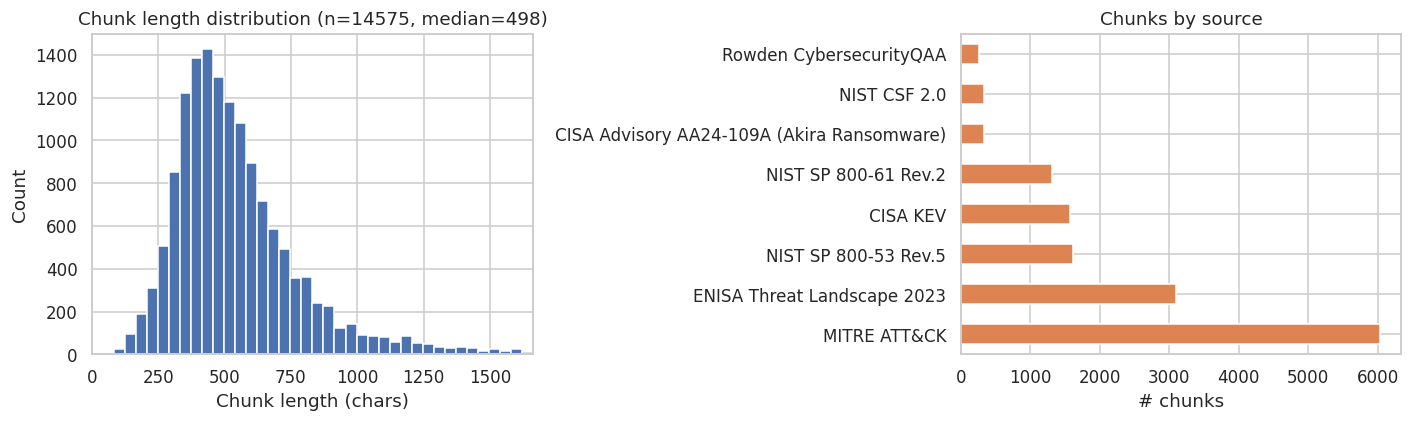

In [20]:
# 可视化：chunk 长度分布与来源分布
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

lengths = np.array([len(c["text"]) for c in all_chunks])
# 用 p99 截断长尾，让分布主体更清晰；尾部 outlier 数量在标题里报告
p99 = int(np.percentile(lengths, 99))
n_above = int((lengths > p99).sum())

# bins 显式限定到 [0, p99]，>p99 的值不会进任何 bin，也不产生右端 spike
axes[0].hist(lengths, bins=np.linspace(0, p99, 41), color="#4C72B0", edgecolor="white")
axes[0].set_xlim(0, p99)
axes[0].set_xlabel("Chunk length (chars)")
axes[0].set_ylabel("Count")
axes[0].set_title(
    f"Chunk length distribution (n={len(all_chunks)}, "
    f"median={int(np.median(lengths))})"
)

src_counts = pd.Series([c["source"] for c in all_chunks]).value_counts()
src_counts.plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_xlabel("# chunks"); axes[1].set_title("Chunks by source")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig_03_chunk_distribution.png", dpi=150, bbox_inches="tight"); plt.show()

## 4. 稠密检索：BAAI/bge-base-en-v1.5 + FAISS

选 `bge-base-en-v1.5` 的理由：
- MTEB retrieval 榜单上英文小模型 SOTA 档位（~0.53 nDCG@10 on BEIR）
- 768 维、仅 109M 参数，CPU 上也能跑
- 训练时引入了 query/passage 的不对称 prompt（`Represent this sentence for searching relevant passages:` 前缀），在检索场景上显著优于通用 sentence-BERT


In [21]:
from sentence_transformers import SentenceTransformer
import faiss

EMB_MODEL = "BAAI/bge-base-en-v1.5"
print(f"加载 embedding 模型: {EMB_MODEL}")
embedder = SentenceTransformer(EMB_MODEL)

corpus_texts = [c["text"] for c in all_chunks]
print("编码 corpus...")
corpus_emb = embedder.encode(
    corpus_texts, batch_size=32, show_progress_bar=True,
    normalize_embeddings=True  # BGE 官方推荐余弦检索归一化
).astype("float32")
print("corpus_emb shape:", corpus_emb.shape)

# FAISS 内积索引（归一化后等价余弦）
faiss_index = faiss.IndexFlatIP(corpus_emb.shape[1])
faiss_index.add(corpus_emb)
print(f"FAISS 索引完成，向量数 = {faiss_index.ntotal}")


加载 embedding 模型: BAAI/bge-base-en-v1.5
编码 corpus...


Batches:   0%|          | 0/456 [00:00<?, ?it/s]

corpus_emb shape: (14575, 768)
FAISS 索引完成，向量数 = 14575


In [22]:
BGE_QUERY_PROMPT = "Represent this sentence for searching relevant passages: "

def dense_search(query: str, k: int = 10) -> List[Tuple[int, float]]:
    q_emb = embedder.encode([BGE_QUERY_PROMPT + query], normalize_embeddings=True).astype("float32")
    scores, idxs = faiss_index.search(q_emb, k)
    return list(zip(idxs[0].tolist(), scores[0].tolist()))

# 测试
for idx, sc in dense_search("How do attackers use spear-phishing to gain initial access?", k=3):
    ch = all_chunks[idx]
    print(f"[{sc:.3f}] {ch['title']} — {ch['text'][:120]}...")


[0.772] T1534 Internal Spearphishing (description) — After they already have access to accounts or systems within the environment, adversaries may use internal spearphishing...
[0.769] T1608.005 Link Target (description) — An adversary may rely upon a user clicking a malicious link in order to divulge information (including credentials) or t...
[0.762] T1608.005 Link Target (description) — Links can be used for spearphishing, such as sending an email accompanied by social engineering text to coax the user to...


In [23]:
import pickle
import numpy as np

# 保存FAISS索引和corpus embeddings
faiss.write_index(faiss_index, str(DATA_DIR / "faiss_index.bin"))
np.save(DATA_DIR / "corpus_emb.npy", corpus_emb)
with open(DATA_DIR / "chunks_list.pkl", "wb") as f:
    pickle.dump(all_chunks, f)
print("FAISS索引已保存")

FAISS索引已保存


## 5. 稀疏检索：BM25

In [24]:
from rank_bm25 import BM25Okapi
import string

STOPWORDS = set("""a an and are as at be but by for from has have he her his i in is it its of on or our she
that the their them they this to was we were what when where which who will with you your""".split())

def tokenize(text: str) -> List[str]:
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\-]", " ", text)
    return [t for t in text.split() if t and t not in STOPWORDS and len(t) > 1]

corpus_tokens = [tokenize(c["text"]) for c in all_chunks]
bm25 = BM25Okapi(corpus_tokens)
print("BM25 索引构建完成")

def sparse_search(query: str, k: int = 10) -> List[Tuple[int, float]]:
    q_tokens = tokenize(query)
    scores = bm25.get_scores(q_tokens)
    idxs = np.argsort(-scores)[:k]
    return [(int(i), float(scores[i])) for i in idxs]

for idx, sc in sparse_search("containment strategy for ransomware incident", k=3):
    ch = all_chunks[idx]
    print(f"[{sc:.3f}] {ch['title']} — {ch['text'][:120]}...")


BM25 索引构建完成
[19.577] NIST SP 800-61r2 — Page 45 — Incident Response Life Cycle (Containment, Eradication, and Recovery) 3.3.1 Choosing a Containment Strategy Containment ...
[18.588] NIST SP 800-61r2 — Page 45 — 3.3 Containment, Eradication, and Recovery Figure 3-3. Incident Response Life Cycle (Containment, Eradication, and Recov...
[16.481] NIST SP 800-61r2 — Page 62 — How would the team prioritize the handling of this incident? (Section 3.2.6) Containment, Eradication, and Recovery: 1. ...


## 6. 混合检索 — Reciprocal Rank Fusion (RRF)

两条检索路径**完全独立**：dense 用余弦，sparse 用 BM25；两者分数量纲不同，直接加权相加不可比。RRF 只看排名，公式：

$$\text{RRF}(d) = \sum_{r \in \{dense, sparse\}} \frac{1}{k + \text{rank}_r(d)}$$

参考 Cormack et al. (2009)，$k=60$ 是文献通用值。


In [25]:
def rrf_hybrid_search(query: str, k_each: int = 20, top_k: int = 3, k_rrf: int = 60):
    dense_hits = dense_search(query, k=k_each)
    sparse_hits = sparse_search(query, k=k_each)

    rank_dense = {doc_id: r+1 for r, (doc_id, _) in enumerate(dense_hits)}
    rank_sparse = {doc_id: r+1 for r, (doc_id, _) in enumerate(sparse_hits)}

    rrf_scores = defaultdict(float)
    for doc_id, r in rank_dense.items():
        rrf_scores[doc_id] += 1.0 / (k_rrf + r)
    for doc_id, r in rank_sparse.items():
        rrf_scores[doc_id] += 1.0 / (k_rrf + r)

    ranked = sorted(rrf_scores.items(), key=lambda x: -x[1])[:top_k]
    results = []
    for doc_id, score in ranked:
        results.append({
            "chunk_id": doc_id,
            "rrf_score": score,
            "dense_rank": rank_dense.get(doc_id, None),
            "sparse_rank": rank_sparse.get(doc_id, None),
            **all_chunks[doc_id]
        })
    return results

# 验证
demo_q = "How should we handle spear-phishing attempts in a mid-sized enterprise?"
print(f"查询: {demo_q}\n")
for h in rrf_hybrid_search(demo_q, top_k=3):
    print(f"[RRF={h['rrf_score']:.4f} dense#{h['dense_rank']} sparse#{h['sparse_rank']}] "
          f"{h['source']} | {h['title']}")
    print(f"  {h['text'][:180]}...\n")


查询: How should we handle spear-phishing attempts in a mid-sized enterprise?

[RRF=0.0296 dense#14 sparse#2] ENISA Threat Landscape 2023 | ENISA Threat Landscape 2023
  Organisations should consider this change in attack surface during the planning phase for the defence. 6.11 RE-EMERGENCE OF CALL-BACK PHISHING Call-back phishing is a hybrid techni...

[RRF=0.0164 dense#1 sparse#None] ENISA Threat Landscape 2023 | ENISA Threat Landscape 2023
  The threat actors employ more and more sophisticated techniques, from the standard spear-phishing e-mail to a compromised company e-mail, to persuade a victim to initiate malicious...

[RRF=0.0164 dense#None sparse#1] NIST SP 800-61 Rev.2 | NIST SP 800-61r2 — Page 78
  11. Create a final report. This report should detail the incident handling process. It also should provide an executive summary of what happened and how a formal incident response ...



## 7. 查询集与Prompt设计

### 7.1 从业者查询集（10条，覆盖不同战术阶段）

覆盖 ATT&CK 的多个战术阶段与多个场景，避免集中在单一领域：

In [26]:
PRACTITIONER_QUERIES = [
    # Execution / Defense Evasion + Incident Response
    "Our EDR flagged a PowerShell process spawning from Word.exe at 2am. Walk me through the triage, containment, and root-cause analysis steps a SOC analyst should follow in the first 60 minutes.",
    # Governance / Compliance
    "Our company must comply with Australia's Privacy Act APP 11. How should we align our incident response process to meet notification obligations within 30 days of a data breach?",
    # Credential Access
    "A financial services CISO asks: how can we defend against adversary-in-the-middle (AiTM) phishing that bypasses push-based MFA?",
    # Persistence
    "Our Linux servers were compromised and we suspect the attacker installed persistent cron jobs and systemd services. What is a practical hunting playbook?",
    # Credential Access / Discovery
    "Users are reporting their accounts are being locked out every morning around 9am. IT says there's no obvious brute force alert. What should we investigate?",
    # Exfiltration / Command and Control
    "What controls should a cloud-native SaaS vendor put in place to detect data exfiltration to attacker-controlled S3 buckets or C2 over DNS?",
    # Incident Response lifecycle
    "As an incident responder, what are the key steps in the containment and eradication phase for a ransomware outbreak on domain-joined Windows hosts?",
    # Vulnerability Management
    "Our organization operates internet-facing VPN concentrators. Given CISA KEV entries around Citrix NetScaler and PAN-OS, what is a prioritized remediation plan?",
    # Cloud Security / Identity
    "How should a small startup with an Azure tenant secure privileged accounts against password-spray and token theft attacks?",
    # Post-Incident / Governance
    "After a confirmed data breach involving customer PII, what lessons-learned and governance follow-up should the CISO drive in the next 30 days?",
    # Threat intel / Trends — ENISA threat landscape
    "As a threat intel analyst preparing the 2024 outlook briefing for our executive team, summarize the dominant ransomware-as-a-service business model shifts and supply-chain attack patterns we should be tracking based on recent threat landscape reporting.",
    # Security architecture / CSF 2.0 alignment
    "We're a 500-person manufacturing company rebuilding our cybersecurity program from scratch. As the incoming security architect, how should I structure our capabilities around the NIST CSF 2.0 six functions, and where do mid-size organizations typically have the largest gaps?",
    # DFIR / Lateral Movement
    "Our SIEM flagged anomalous SMB and WMI activity originating from a single compromised workstation toward several finance department hosts. As a DFIR lead, walk me through the lateral movement hunt — which Windows event IDs, registry artifacts, and ATT&CK techniques should we triangulate on?",
    # Sysadmin / Preparation phase (NIST 800-61)
    "I'm a sysadmin at a 200-person professional services firm with no documented incident response program. What concrete preparation activities should I have in place before an incident actually happens?",
    # Identity engineering / Discovery
    "Our Azure AD audit logs show repeated enumeration of group memberships and service principal credentials from a non-corporate IP range. As the identity engineering lead, which discovery techniques should I monitor and what hardening controls reduce attack surface here?",
    # AppSec / Supply Chain (Initial Access)
    "After a peer organization disclosed a build-system compromise via a poisoned npm dependency, our AppSec team wants to harden our CI/CD pipeline. What threat model, detections, and source-integrity controls should we put in place against software supply-chain attacks?",
    # Tabletop / Cross-source multi-hop reasoning
    "I'm running a tabletop exercise next month for a domain controller compromise scenario. Help me map: (a) the most likely ATT&CK technique chain, (b) the NIST 800-53 controls that should fire during each phase, and (c) what CSF 2.0 Respond function activities the IR team would execute.",
    # Out-of-corpus probe (hallucination test — CrowdStrike is not in knowledge base)
    "Our team uses CrowdStrike Falcon as our primary EDR. What detection rules and IOA configurations does CrowdStrike recommend for catching process injection on Windows servers?",
    # Risk / Impact quantification / Post-Incident
    "After a 4-day operational disruption from a ransomware event affecting our ERP and EDI systems, as the risk manager I need to quantify the loss for board reporting. What financial, regulatory, contractual, and reputational impact dimensions should the post-incident analysis cover?",
    # Threat hunting / Reconnaissance (pre-compromise)
    "We've observed unusual scanning patterns against our public-facing services and OSINT collection targeting our engineering team's LinkedIn profiles. As a threat hunter, what pre-compromise reconnaissance indicators should we track, and what defenses reduce the attacker's pre-attack intel value?",
]
for i, q in enumerate(PRACTITIONER_QUERIES, 1):
    print(f"Q{i}. {q}")


Q1. Our EDR flagged a PowerShell process spawning from Word.exe at 2am. Walk me through the triage, containment, and root-cause analysis steps a SOC analyst should follow in the first 60 minutes.
Q2. Our company must comply with Australia's Privacy Act APP 11. How should we align our incident response process to meet notification obligations within 30 days of a data breach?
Q3. A financial services CISO asks: how can we defend against adversary-in-the-middle (AiTM) phishing that bypasses push-based MFA?
Q4. Our Linux servers were compromised and we suspect the attacker installed persistent cron jobs and systemd services. What is a practical hunting playbook?
Q5. Users are reporting their accounts are being locked out every morning around 9am. IT says there's no obvious brute force alert. What should we investigate?
Q6. What controls should a cloud-native SaaS vendor put in place to detect data exfiltration to attacker-controlled S3 buckets or C2 over DNS?
Q7. As an incident responder, 

### 7.2 Prompt设计：完整版 A vs 简化版 B（对比实验）

### 版本 A — 四层结构（System / Context / Query / Output Instruction）
对应题意中的完整 prompt：角色约束、上下文注入（带来源标签）、用户查询、输出格式约束。

### 版本 B — 简化对照
只用单条 user message："You are a security expert, answer this question: {query}\n\nReference: {ctx}"

**假设**：版本 A 的引用约束应能抑制幻觉，提高 Faithfulness；版本 B 更自由但可能偏离来源。

In [27]:
def format_context(hits: List[Dict]) -> str:
    blocks = []
    for i, h in enumerate(hits, 1):
        tag = h["source"]
        extra = ""
        if h.get("technique_id"):
            extra = f" [{h['technique_id']} {h['technique_name']} — {h['field']}]"
        blocks.append(f"[Source {i}] ({tag}{extra})\n{h['text']}\n")
    return "\n".join(blocks)

SYSTEM_PROMPT_A = (
    "You are a senior cybersecurity advisor writing actionable guidelines for practitioners. "
    "Follow these rules strictly:\n"
    "1. Ground every recommendation in the provided SOURCES; cite them inline as [Source N].\n"
    "2. If the sources do not support a claim, say 'Not covered by retrieved sources'.\n"
    "3. Produce a structured response. Use whichever format best matches the practitioner's question:\n"
    "   - For procedural questions ('walk me through', 'what steps', 'playbook'): numbered chronological steps\n"
    "   - For advisory questions ('how should we', 'what controls', 'recommendations'): numbered recommendations\n"
    "   - For mapping / multi-part questions (e.g. '(a)…(b)…(c)…'): mirror the structure the query requests\n"
    "   - For each item include: a one-line action statement, 'Why:' (1-2 sentences), 'How:' (1-2 sentences), and [Source N] citation(s)\n"
    "   - Produce between 3 and 6 items, unless the query explicitly asks for a specific number\n"
    "4. Keep the total response under 600 words.\n"
    "5. Add a final 'Limitations:' line noting any aspects of the query not supported by sources.\n"
    "6. Do not invent CVE IDs, product names, or statistics not present in the sources."
)

def build_messages_A(query: str, hits: List[Dict]) -> List[Dict]:
    ctx = format_context(hits)
    user = (f"SOURCES:\n{ctx}\n\nPRACTITIONER QUERY:\n{query}\n\n"
            f"Respond following the output format defined in the system instructions.")
    return [{"role": "system", "content": SYSTEM_PROMPT_A},
            {"role": "user", "content": user}]

def build_messages_B(query: str, hits: List[Dict]) -> List[Dict]:
    ctx = "\n\n".join([h["text"] for h in hits])
    user = f"You are a security expert, answer this question: {query}\n\nReference:\n{ctx}"
    return [{"role": "user", "content": user}]

# 快速对比打印（不依赖 tokenizer，直接展示 messages 结构）
demo_hits = rrf_hybrid_search(PRACTITIONER_QUERIES[0], top_k=3)
for label, msgs in [
    ("Prompt A", build_messages_A(PRACTITIONER_QUERIES[0], demo_hits)),
    ("Prompt B", build_messages_B(PRACTITIONER_QUERIES[0], demo_hits)),
]:
    print(f"\n=== {label} ===")
    for msg in msgs:
        role = msg['role'].upper()
        content = msg['content'][:500]
        print(f"[{role}]\n{content}\n...(截断)\n")



=== Prompt A ===
[SYSTEM]
You are a senior cybersecurity advisor writing actionable guidelines for practitioners. Follow these rules strictly:
1. Ground every recommendation in the provided SOURCES; cite them inline as [Source N].
2. If the sources do not support a claim, say 'Not covered by retrieved sources'.
3. Produce a structured response. Use whichever format best matches the practitioner's question:
   - For procedural questions ('walk me through', 'what steps', 'playbook'): numbered chronological steps
   - For a
...(截断)

[USER]
SOURCES:
[Source 1] (MITRE ATT&CK [T1204.002 Malicious File — detection])
User Execution – Malicious File via download/open → spawn chain (T1204.002) / Analytic 0819: User opens a file delivered by email, web, chat, or share. The handler application (Word/PDF reader/archiver) creates a file in user-controlled paths (Downloads, Temp, Desktop) and then spawns a new or unusual child process (e.g., powershell.exe, wscript.exe, cmd.exe, regsvr32.exe, rundll

## 8. 模型配置

定义候选 LLM 列表及加载/卸载工具函数。以 4-bit 量化（NF4）加载以适配单卡显存。

| 模型 | 参数量 | 量化 |
|------|--------|------|
| Meta-Llama-3-8B-Instruct | 8B | 4-bit NF4 |
| Qwen2.5-7B-Instruct | 7B | 4-bit NF4 |
| Phi-3.5-mini-instruct | 3.8B | 4-bit NF4 |

In [28]:
import torch, gc
from getpass import getpass
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

if "HF_TOKEN" not in os.environ:
    os.environ["HF_TOKEN"] = getpass("输入HF Token: ")
hf_token = os.environ["HF_TOKEN"]

# ── 候选模型列表（按需增减）──
LLM_CANDIDATES = {
    "Llama-3-8B":   "meta-llama/Meta-Llama-3-8B-Instruct",
    "Qwen2.5-7B":   "Qwen/Qwen2.5-7B-Instruct",
    "Phi-3.5-mini": "microsoft/Phi-3.5-mini-instruct",
}

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
)

def load_llm(model_path: str):
    tok = AutoTokenizer.from_pretrained(model_path, token=hf_token)
    mdl = AutoModelForCausalLM.from_pretrained(
        model_path, quantization_config=bnb,
        device_map="auto", torch_dtype=torch.bfloat16,
        token=hf_token
    )
    mdl.eval()
    return tok, mdl

def make_chat(tok, mdl):
    def chat(messages, max_new_tokens=512, temperature=0.2):
        prompt = tok.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        inputs = tok(prompt, return_tensors="pt").to(mdl.device)
        with torch.no_grad():
            out = mdl.generate(
                **inputs, max_new_tokens=max_new_tokens,
                do_sample=(temperature > 0),
                temperature=max(temperature, 0.01),
                top_p=0.9, pad_token_id=tok.eos_token_id,
            )
        return tok.decode(
            out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True
        ).strip()
    return chat

def unload(tok, mdl):
    del tok, mdl
    gc.collect()
    torch.cuda.empty_cache()
    print("  显存已释放")

def model_tag(name: str) -> str:
    return name.lower().replace("-", "_").replace(".", "_")

print("✓ 模型配置函数定义完成")
print("候选模型:", list(LLM_CANDIDATES.keys()))

输入HF Token:  ········


✓ 模型配置函数定义完成
候选模型: ['Llama-3-8B', 'Qwen2.5-7B', 'Phi-3.5-mini']


## 9. RAGAS评估后端初始化

RAGAS 库使用 OpenRouter GPT-4o-mini 作为评估 LLM，本地 BGE 作为嵌入模型。  
此配置只需初始化一次，后续循环中复用。

### 评估设计取舍：为什么同时跑 manual + library

RAG 评估有两种主流做法，本 notebook **同时采用**，互为对照：

| 路线 | 裁判 | 优势 | 局限 |
|---|---|---|---|
| **Manual**（`eval_manual_cr/ar/faith`）| 被评估的本地小模型自己 | 离线可复现；评估和生成同模型可暴露内部一致性 | **裁判 == 选手**：self-preference bias、capability ceiling |
| **Library**（RAGAS via `eval_ragas`）| OpenRouter GPT-4o-mini | 外部更强模型当裁判，规避 self-eval 闭环 | 依赖外部 API；闭源模型版本漂移可能影响可复现性 |

两套同时跑会让评估时间翻倍，但产生的对比是作业 trustworthiness 讨论的核心实证（见 §11.5 散点图与 §12.4 讨论）。生产环境中，**裁判必须独立于被评模型**；本 notebook 用 manual + library 的差异量化这种独立性带来的影响幅度。

In [29]:
# !pip install -q ragas langchain-huggingface langchain langchain-openai datasets

In [30]:
from ragas.metrics import faithfulness, LLMContextPrecisionWithoutReference
from ragas.metrics import AnswerRelevancy
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.run_config import RunConfig
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from datasets import Dataset

try:
    if "OPENROUTER_KEY" not in os.environ:
        os.environ["OPENROUTER_KEY"] = getpass("输入OpenRouter API key: ")

    ragas_llm = LangchainLLMWrapper(
        ChatOpenAI(
            model="openai/gpt-4o-mini",
            openai_api_key=os.environ["OPENROUTER_KEY"],
            openai_api_base="https://openrouter.ai/api/v1",
            max_tokens=2048,
            temperature=0.1,
        )
    )
    run_config = RunConfig(max_workers=1, max_retries=3, timeout=120)
    ragas_emb  = LangchainEmbeddingsWrapper(
        HuggingFaceEmbeddings(model_name="BAAI/bge-base-en-v1.5")
    )
    context_metric = LLMContextPrecisionWithoutReference()
    # AnswerRelevancy 默认 strictness=3，但 OpenRouter 不传递 n>1 参数 → 触发 warning。
    # 显式设 strictness=1 与实际行为对齐：每个 query 单次反推 1 个问题。
    answer_relevancy_v1 = AnswerRelevancy(strictness=1)
    RAGAS_AVAILABLE = True
    print("✓ RAGAS backend 初始化成功（OpenRouter GPT-4o-mini + 本地BGE, AnswerRelevancy strictness=1）")
except Exception as e:
    print("⚠ RAGAS backend 初始化失败:", e)
    RAGAS_AVAILABLE = False

输入OpenRouter API key:  ········


✓ RAGAS backend 初始化成功（OpenRouter GPT-4o-mini + 本地BGE, AnswerRelevancy strictness=1）


## 10. 多模型循环：训练 → 评估 → 保存

按顺序对 `LLM_CANDIDATES` 中每个模型依次执行：
1. 加载模型（4-bit 量化）
2. 对 10 条查询运行 Prompt A + Prompt B 两版 pipeline
3. 检索质量评估（LLM-as-judge + 关键词重叠 + 嵌入相似度）
4. 手动 RAGAS 三指标（Context Relevance / Answer Relevance / Faithfulness）
5. RAGAS 官方库评估（若 backend 可用）
6. 保存所有结果到 `rag_data/`
7. 卸载模型、释放显存

已有结果文件的模型会**自动跳过**，支持断点续跑。

In [31]:
# ── Pipeline 执行函数 ──
def run_pipeline(queries: List[str], prompt_builder, label: str, llm_chat_fn) -> List[Dict]:
    records = []
    for qi, q in enumerate(queries):
        hits = rrf_hybrid_search(q, top_k=3)
        messages = prompt_builder(q, hits)
        t0 = time.time()
        answer = llm_chat_fn(messages, max_new_tokens=420, temperature=0.2)
        dt = time.time() - t0
        records.append({
            "qid": qi + 1, "prompt_version": label,
            "query": q, "hits": hits, "answer": answer, "latency_s": dt,
        })
        print(f"  [{label}] Q{qi+1} done in {dt:.1f}s")
    return records

print("✓ run_pipeline 定义完成")

✓ run_pipeline 定义完成


In [32]:
# ── 评估工具函数（按 RAGAS 论文 §3 重构）──
# 改动总览（vs 上一版）：
#   Opt 1: VERIFY_SYS 改为 CoT-before-verdict（先 explanation 再 supported）
#   Opt 2: CR_SYS 加 "Insufficient Information" 拒答出口（论文原文）
#   Opt 3: 每个 prompt 加 1 个 few-shot demonstration（论文 footnote 3）
#   Opt 4: eval_manual_ar 改为 N 次独立采样、每次 1 个问题（论文 Eq.1）

BGE_QUERY_PROMPT = "Represent this sentence for searching relevant passages: "

JUDGE_SYSTEM = (
    "You are a strict relevance grader. Given a user query and a retrieved passage, "
    "output ONLY a single JSON object: "
    '{"score": <0|0.25|0.5|0.75|1>, "reason": "<≤20 words>"}. '
    "1.0 = directly answers the query; 0.5 = partial / adjacent topic; 0 = unrelated."
)

# ── Opt 2 + 3: CR 加 insufficient 出口 + few-shot demo ──
CR_SYS = (
    "Extract from the CONTEXT only the sentences that are strictly necessary to answer the QUERY. "
    "You are NOT allowed to make any changes to sentences from the given context — extract them verbatim. "
    "If no relevant sentences are found OR if the question cannot be answered from the given context, "
    'set "insufficient" to true and "relevant" to []. '
    'Otherwise set "insufficient" to false. '
    'Output JSON on the FIRST line: {"relevant": ["sentence1", ...], "insufficient": true|false}. '
    "Do not write any preamble, explanation, or markdown code fences. Return ONLY JSON.\n\n"
    "Example:\n"
    "QUERY: When did the Apollo 11 mission land on the Moon?\n"
    "CONTEXT: Apollo 11 was the spaceflight that first landed humans on the Moon. "
    "Commander Neil Armstrong and lunar module pilot Buzz Aldrin landed the Apollo Lunar Module Eagle on July 20, 1969. "
    "The mission launched on July 16, 1969 from Kennedy Space Center.\n"
    'OUTPUT: {"relevant": ["Apollo 11 was the spaceflight that first landed humans on the Moon.", '
    '"Commander Neil Armstrong and lunar module pilot Buzz Aldrin landed the Apollo Lunar Module Eagle on July 20, 1969."], '
    '"insufficient": false}'
)

# ── Opt 3 + 4: AR 改单问题、加 few-shot demo ──
AR_SYS = (
    "Given the ANSWER, generate ONE question that this answer could be an appropriate response to. "
    "The question should be specific enough that the answer naturally addresses it. "
    'Output JSON: {"question": "<question text>"}. Return ONLY JSON.\n\n'
    "Example:\n"
    "ANSWER: Suspected phishing emails should be reported to the security team via the dedicated reporting button "
    "in Outlook. Users should not click any links, download attachments, or reply to the sender.\n"
    'OUTPUT: {"question": "How should employees handle suspected phishing emails in Outlook?"}'
)

# ── Opt 3: CLAIM 加 few-shot demo ──
CLAIM_SYS = (
    "Decompose the ANSWER into atomic, verifiable claims. "
    "Each claim must be a single-subject self-contained statement. "
    'Output JSON: {"claims": ["claim1", ...]}. Return ONLY JSON.\n\n'
    "Example:\n"
    "ANSWER: PowerShell is a scripting language developed by Microsoft. When abused by attackers, "
    "it enables fileless execution and lateral movement. Defenders should enable Constrained Language Mode "
    "to mitigate these risks.\n"
    'OUTPUT: {"claims": ['
    '"PowerShell is a scripting language.", '
    '"PowerShell is developed by Microsoft.", '
    '"Attackers can abuse PowerShell for fileless execution.", '
    '"Attackers can abuse PowerShell for lateral movement.", '
    '"Defenders should enable Constrained Language Mode to mitigate PowerShell-related risks."'
    "]}"
)

# ── Opt 1 + 3: VERIFY 改 CoT-before-verdict + few-shot ──
VERIFY_SYS = (
    "Given a CONTEXT and a CLAIM, determine whether the claim is supported by the information in the context. "
    "Provide a brief explanation FIRST, then arrive at the final verdict. "
    'Output JSON with explanation BEFORE supported: '
    '{"explanation": "<reasoning, ≤30 words>", "supported": true|false}. '
    "Return ONLY JSON.\n\n"
    "Example:\n"
    "CONTEXT: Phishing emails commonly impersonate trusted entities like banks. They often contain urgent "
    "requests to verify account details by clicking a link.\n"
    "CLAIM: Phishing emails primarily use SMS as the delivery channel.\n"
    'OUTPUT: {"explanation": "Context discusses email phishing impersonating banks; SMS-based phishing (smishing) is a distinct concept not mentioned.", '
    '"supported": false}'
)

CR_EMBED_THRESHOLD = 0.85  # 论文要求 verbatim 提取，阈值提高（旧值 0.70 是 fuzzy）


def _llm_json_retry(llm_chat_fn, msgs, default, max_new_tokens=200, retries=2):
    """带重试的 LLM JSON 调用。返回 (parsed_dict, ok_flag)。"""
    for attempt in range(retries + 1):
        temp = 0.0 if attempt == 0 else 0.2 + 0.1 * (attempt - 1)
        raw = llm_chat_fn(msgs, max_new_tokens=max_new_tokens, temperature=temp)
        try:
            m = re.search(r"\{.*\}", raw, flags=re.S)
            if m:
                return json.loads(m.group(0)), True
        except Exception:
            pass
    return default, False


def eval_retrieval(records_A: List[Dict], llm_chat_fn) -> pd.DataFrame:
    rows, n_fail = [], 0
    for rec in records_A:
        for rank, h in enumerate(rec["hits"], 1):
            q, p = rec["query"], h["text"]
            msgs = [{"role": "system", "content": JUDGE_SYSTEM},
                    {"role": "user", "content": f"QUERY:\n{q}\n\nPASSAGE:\n{p}\n\nReturn JSON."}]
            obj, ok = _llm_json_retry(llm_chat_fn, msgs, {"score": 0.0}, max_new_tokens=80)
            if not ok:
                n_fail += 1
                llm_score = float('nan')
            else:
                try:
                    llm_score = float(obj.get("score", 0.0))
                except Exception:
                    llm_score = float('nan')
            qw, pw = set(tokenize(q)), set(tokenize(p))
            kw = len(qw & pw) / len(qw | pw) if (qw | pw) else 0.0
            vecs = embedder.encode([BGE_QUERY_PROMPT + q, p], normalize_embeddings=True)
            emb = float(np.dot(vecs[0], vecs[1]))
            rows.append({"qid": rec["qid"], "rank": rank,
                         "query": q, "chunk_id": h["chunk_id"],
                         "source": h["source"], "title": h["title"],
                         "llm_score": llm_score, "kw_overlap": kw, "emb_sim": emb})
    df = pd.DataFrame(rows)
    if n_fail:
        print(f"  ⚠ LLM-judge JSON 解析失败 {n_fail} 条（已记 NaN）")
    print("  检索评估完成:", df.groupby("rank")[["llm_score","kw_overlap","emb_sim"]].mean().round(3).to_dict())
    return df


def eval_manual_cr(records_all: List[Dict], llm_chat_fn) -> pd.DataFrame:
    """Context Relevance（论文 §3）：LLM 提取 verbatim 相关句，逐字匹配回上下文。
    A/B 共享检索 → 按 qid 缓存。新增 insufficient 字段（论文 'Insufficient Information' 出口）。"""
    rows = []
    cache = {}  # qid -> (manual_cr, insufficient)
    n_fail = 0
    for rec in records_all:
        qid = rec["qid"]
        if qid not in cache:
            contexts = [h["text"] for h in rec["hits"]]
            joined = " ".join(contexts)
            sents = sentence_split(joined)
            msgs = [{"role":"system","content": CR_SYS},
                    {"role":"user","content": f"QUERY:\n{rec['query']}\n\nCONTEXT:\n{joined}"}]
            obj, ok = _llm_json_retry(llm_chat_fn, msgs, {"relevant": [], "insufficient": True}, max_new_tokens=1024)
            insufficient = bool(obj.get("insufficient", False))
            rel = [r for r in obj.get("relevant", []) if r and len(r.strip()) > 5]
            if not ok:
                n_fail += 1
                cache[qid] = (float('nan'), False)
            elif insufficient or not rel:
                cache[qid] = (0.0, insufficient)
            elif not sents:
                cache[qid] = (0.0, False)
            else:
                v_rel   = embedder.encode(rel, normalize_embeddings=True)
                v_sents = embedder.encode(sents, normalize_embeddings=True)
                max_sim = (v_sents @ v_rel.T).max(axis=1)
                hits = int((max_sim >= CR_EMBED_THRESHOLD).sum())
                cache[qid] = (hits / max(1, len(sents)), False)
        cr_val, insuf = cache[qid]
        rows.append({"qid": qid, "prompt_version": rec["prompt_version"],
                     "manual_cr": cr_val, "cr_insufficient": insuf})
    df = pd.DataFrame(rows)
    if n_fail:
        print(f"  ⚠ CR JSON 解析失败 {n_fail} 条（已记 NaN）")
    n_insuf = df.drop_duplicates("qid")["cr_insufficient"].sum()
    if n_insuf:
        print(f"  ℹ {n_insuf} 个 qid 被标为 insufficient（context 不足以回答 → 测试 out-of-corpus 鲁棒性）")
    print("  CR done:", df.groupby("prompt_version")["manual_cr"].mean().round(3).to_dict())
    return df


def eval_manual_ar(records_all: List[Dict], llm_chat_fn, n_samples: int = 3) -> pd.DataFrame:
    """Answer Relevance（论文 Eq.1）：N 次独立采样，每次只生成 1 个问题，
    与原 query 算 cosine 后平均。temperature 在 [0.3, 0.6] 区间扫描以保证多样性。"""
    rows = []
    n_fail = 0
    for rec in records_all:
        msgs = [{"role":"system","content": AR_SYS},
                {"role":"user","content": f"ANSWER:\n{rec['answer']}"}]
        qs = []
        for i in range(n_samples):
            temp = 0.3 + 0.15 * i  # 0.30, 0.45, 0.60
            raw = llm_chat_fn(msgs, max_new_tokens=150, temperature=temp)
            try:
                m = re.search(r"\{.*\}", raw, flags=re.S)
                if m:
                    obj = json.loads(m.group(0))
                    q = (obj.get("question") or "").strip()
                    if q:
                        qs.append(q)
            except Exception:
                pass

        if not qs:
            n_fail += 1
            ar = float('nan')
        else:
            v_orig = embedder.encode([rec['query']], normalize_embeddings=True)
            v_gen  = embedder.encode(qs, normalize_embeddings=True)
            ar = float((v_gen @ v_orig.T).flatten().mean())
        rows.append({"qid": rec["qid"], "prompt_version": rec["prompt_version"],
                     "manual_ar": ar, "n_ar_samples": len(qs)})
    df = pd.DataFrame(rows)
    if n_fail:
        print(f"  ⚠ AR 所有采样都失败 {n_fail} 条（已记 NaN）")
    avg_samples = df["n_ar_samples"].mean()
    print(f"  AR done (平均 {avg_samples:.1f}/{n_samples} 次有效采样):",
          df.groupby("prompt_version")["manual_ar"].mean().round(3).to_dict())
    return df


def eval_manual_faith(records_all: List[Dict], llm_chat_fn) -> Tuple[pd.DataFrame, List[Dict]]:
    """Faithfulness（论文 §3）：先把 answer 拆 atomic claims，再对每个 claim 做 CoT-before-verdict
    的逐条验证。verify_sys 已要求 explanation 在 supported 之前生成。"""
    rows, raw_faith = [], []
    n_extract_fail, n_verify_fail = 0, 0
    for rec in records_all:
        ctx = "\n\n".join([h["text"] for h in rec["hits"]])
        obj, ok = _llm_json_retry(
            llm_chat_fn,
            [{"role":"system","content": CLAIM_SYS},
             {"role":"user","content": f"ANSWER:\n{rec['answer']}"}],
            {"claims": []}, max_new_tokens=1024)
        claims = obj.get("claims", [])
        if not ok or not claims:
            if not ok: n_extract_fail += 1
            rows.append({"qid": rec["qid"], "prompt_version": rec["prompt_version"],
                         "manual_faith": float('nan'),
                         "n_claims": 0, "n_supported": 0,
                         "extraction_ok": ok, "verdicts": []})
            continue
        verdicts, supported, n_unverified = [], 0, 0
        for c in claims:
            obj2, ok2 = _llm_json_retry(
                llm_chat_fn,
                [{"role":"system","content": VERIFY_SYS},
                 {"role":"user","content": f"CONTEXT:\n{ctx}\n\nCLAIM:\n{c}"}],
                {"explanation": "", "supported": False}, max_new_tokens=300)
            if not ok2:
                n_unverified += 1
                n_verify_fail += 1
                verdicts.append({"claim": c, "supported": None,
                                 "explanation": "verify failed"})
            else:
                sup = bool(obj2.get("supported", False))
                if sup: supported += 1
                verdicts.append({"claim": c, "supported": sup,
                                 "explanation": obj2.get("explanation","")})
        n_valid = len(claims) - n_unverified
        faith_score = (supported / n_valid) if n_valid > 0 else float('nan')
        rows.append({"qid": rec["qid"], "prompt_version": rec["prompt_version"],
                     "manual_faith": faith_score, "n_claims": len(claims),
                     "n_supported": supported, "extraction_ok": True,
                     "verdicts": verdicts})
        raw_faith.append({**rows[-1], "query": rec["query"]})
    df = pd.DataFrame([{k:v for k,v in r.items() if k != "verdicts"} for r in rows])
    if n_extract_fail:
        print(f"  ⚠ Claim 提取失败 {n_extract_fail} 条（manual_faith = NaN）")
    if n_verify_fail:
        print(f"  ⚠ Claim 验证失败 {n_verify_fail} 条（不计入分母）")
    print("  Faith done:", df.groupby("prompt_version")["manual_faith"].mean().round(3).to_dict())
    return df, rows


def eval_lib_cr_paper_style(records_all: List[Dict]) -> pd.DataFrame:
    """论文 §3 句子级 CR，但裁判换成 GPT-4o-mini（外部强模型）。
    与 manual_cr 算法一致，唯一变量是裁判 → 散点对齐可直接反映"裁判能力差"。
    每 qid 只调一次（A/B 共享检索），20 次 GPT 调用，成本可忽略。"""
    if not RAGAS_AVAILABLE:
        print("  RAGAS backend 不可用，跳过 lib_cr_paper")
        return pd.DataFrame(columns=["qid", "prompt_version", "lib_cr_paper"])

    # 用 langchain 直接调 GPT-4o-mini（不走 LangchainLLMWrapper 包装）
    from langchain_openai import ChatOpenAI
    from langchain_core.messages import SystemMessage, HumanMessage
    gpt = ChatOpenAI(
        model="openai/gpt-4o-mini",
        openai_api_key=os.environ["OPENROUTER_KEY"],
        openai_api_base="https://openrouter.ai/api/v1",
        max_tokens=2048, temperature=0.0,
    )

    rows = []
    cache = {}
    n_fail = 0
    for rec in records_all:
        qid = rec["qid"]
        if qid not in cache:
            contexts = [h["text"] for h in rec["hits"]]
            joined = " ".join(contexts)
            sents = sentence_split(joined)
            lc_msgs = [SystemMessage(content=CR_SYS),
                       HumanMessage(content="QUERY:\n" + rec["query"] + "\n\nCONTEXT:\n" + joined)]
            try:
                response = gpt.invoke(lc_msgs).content
                m = re.search(r"\{.*\}", response, flags=re.S)
                obj = json.loads(m.group(0)) if m else {"relevant": [], "insufficient": True}
            except Exception:
                n_fail += 1
                obj = {"relevant": [], "insufficient": True}

            rel = [r for r in obj.get("relevant", []) if r and len(r.strip()) > 5]
            insufficient = bool(obj.get("insufficient", False))
            if insufficient or not rel or not sents:
                cache[qid] = 0.0
            else:
                v_rel   = embedder.encode(rel, normalize_embeddings=True)
                v_sents = embedder.encode(sents, normalize_embeddings=True)
                max_sim = (v_sents @ v_rel.T).max(axis=1)
                hits = int((max_sim >= CR_EMBED_THRESHOLD).sum())
                cache[qid] = hits / max(1, len(sents))
        rows.append({"qid": qid, "prompt_version": rec["prompt_version"],
                     "lib_cr_paper": cache[qid]})

    df = pd.DataFrame(rows)
    if n_fail:
        print(f"  ⚠ Lib-CR-paper {n_fail} 个 qid GPT 调用失败")
    print(f"  Lib-CR-paper done: {df.groupby('prompt_version')['lib_cr_paper'].mean().round(3).to_dict()}")
    return df


def eval_ragas(records_A: List[Dict], records_B: List[Dict]) -> pd.DataFrame | None:
    if not RAGAS_AVAILABLE:
        return None
    ds_A = build_ragas_ds(records_A)
    ds_B = build_ragas_ds(records_B)
    ctx_m = LLMContextPrecisionWithoutReference()
    sa = evaluate(ds_A, metrics=[ctx_m, answer_relevancy_v1, faithfulness],
                  llm=ragas_llm, embeddings=ragas_emb).to_pandas()
    sb = evaluate(ds_B, metrics=[ctx_m, answer_relevancy_v1, faithfulness],
                  llm=ragas_llm, embeddings=ragas_emb).to_pandas()
    sa["prompt_version"] = "A_full"
    sb["prompt_version"] = "B_simple"
    return pd.concat([sa, sb], ignore_index=True)


def merge_eval(df_cr, df_ar, df_faith_df, ragas_lib) -> pd.DataFrame:
    df = df_cr.merge(df_ar, on=["qid","prompt_version"]) \
               .merge(df_faith_df[["qid","prompt_version","manual_faith","n_claims","n_supported"]],
                      on=["qid","prompt_version"])
    if ragas_lib is not None:
        rl = ragas_lib.reset_index(drop=True).copy()
        n_per_version = len(rl) // 2 if len(rl) % 2 == 0 else len(rl)
        rl["qid"] = (rl.index % n_per_version) + 1
        rl = rl.rename(columns={
            "llm_context_precision_without_reference": "lib_cr",
            "answer_relevancy": "lib_ar",
            "faithfulness": "lib_faith"
        })[["qid","prompt_version","lib_cr","lib_ar","lib_faith"]]
        df = df.merge(rl, on=["qid","prompt_version"], how="left")
    else:
        df["lib_cr"]    = df["manual_cr"]
        df["lib_ar"]    = df["manual_ar"]
        df["lib_faith"] = df["manual_faith"]
    return df


print("✓ 所有评估函数定义完成（按 RAGAS 论文 §3 重构）")

✓ 所有评估函数定义完成（按 RAGAS 论文 §3 重构）


In [33]:
# ══════════════════════════════════════════════════════════
# 主循环：对每个模型依次训练 + 评估 + 保存
# ══════════════════════════════════════════════════════════

for model_name, model_path in LLM_CANDIDATES.items():
    tag = model_tag(model_name)
    eval_csv = DATA_DIR / f"eval_{tag}.csv"

    if eval_csv.exists():
        print(f"⏭  {model_name} 已有结果，跳过（删除 {eval_csv.name} 可重跑）")
        continue

    print(f"\n{'═'*62}")
    print(f"▶  模型: {model_name}")
    print('═'*62)

    # 1. 加载模型
    tokenizer, llm = load_llm(model_path)
    llm_chat = make_chat(tokenizer, llm)
    print(f"✓ {model_name} 加载完成")

    # 2. 运行 pipeline（Prompt A + B）
    print("\n[2/8] 运行 pipeline...")
    records_A = run_pipeline(PRACTITIONER_QUERIES, build_messages_A, "A_full",   llm_chat)
    records_B = run_pipeline(PRACTITIONER_QUERIES, build_messages_B, "B_simple", llm_chat)
    all_records_cur = records_A + records_B

    # 3. 保存 pipeline 结果
    with open(DATA_DIR / f"records_{tag}.pkl", "wb") as f:
        pickle.dump({"A": records_A, "B": records_B, "all": all_records_cur}, f)
    print(f"✓ Pipeline 结果已保存 → records_{tag}.pkl")

    # 4. 检索质量评估
    print("\n[4/8] 检索质量评估...")
    df_ret = eval_retrieval(records_A, llm_chat)
    df_ret["model"] = model_name
    df_ret.to_csv(DATA_DIR / f"retrieval_eval_{tag}.csv", index=False)
    print(f"✓ 检索评估已保存 → retrieval_eval_{tag}.csv")

    # 5. 手动 RAGAS 三指标
    print("\n[5/8] 手动 Context Relevance...")
    df_cr = eval_manual_cr(all_records_cur, llm_chat)

    print("\n[6/8] 手动 Answer Relevance...")
    df_ar = eval_manual_ar(all_records_cur, llm_chat)

    print("\n[7/8] 手动 Faithfulness...")
    df_faith, faith_raw = eval_manual_faith(all_records_cur, llm_chat)

    # 6. RAGAS 官方库评估
    print("\n[8/8] RAGAS 库评估...")
    ragas_lib = eval_ragas(records_A, records_B)
    if ragas_lib is not None:
        ragas_lib.to_csv(DATA_DIR / f"ragas_lib_{tag}.csv", index=False)
        print(f"✓ RAGAS库结果已保存 → ragas_lib_{tag}.csv")
    else:
        print("  RAGAS库不可用，使用手动指标替代")

    # 6.5 Library CR with paper §3 algorithm (apples-to-apples with manual_cr)
    print("\n[8b] Lib-CR paper-style (GPT-4o-mini + sentence-level)...")
    df_cr_paper = eval_lib_cr_paper_style(all_records_cur)

    # 7. 合并评估结果
    df_eval = merge_eval(df_cr, df_ar, df_faith, ragas_lib)
    if len(df_cr_paper) > 0:
        df_eval = df_eval.merge(df_cr_paper, on=["qid","prompt_version"], how="left")
    df_eval["model"] = model_name
    df_eval.to_csv(eval_csv, index=False)
    print(f"✓ 综合评估已保存 → {eval_csv.name}")

    # 8. 保存完整手动评估（含 verdicts）
    with open(DATA_DIR / f"manual_eval_{tag}.pkl", "wb") as f:
        pickle.dump({
            "df_manual_cr":    df_cr,
            "df_manual_ar":    df_ar,
            "df_manual_faith": df_faith,
            "faith_raw":       faith_raw,
            "df_eval":         df_eval,
        }, f)
    print(f"✓ 完整手动评估已保存 → manual_eval_{tag}.pkl")

    # 9. 卸载模型
    unload(tokenizer, llm)
    print(f"✓ {model_name} 全部完成\n")

print("\n" + "═"*62)
print("所有模型处理完成！结果保存在 ./rag_data/")
print("═"*62)


══════════════════════════════════════════════════════════════
▶  模型: Llama-3-8B
══════════════════════════════════════════════════════════════


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✓ Llama-3-8B 加载完成

[2/8] 运行 pipeline...
  [A_full] Q1 done in 7.0s
  [A_full] Q2 done in 6.0s
  [A_full] Q3 done in 4.5s
  [A_full] Q4 done in 6.9s
  [A_full] Q5 done in 5.1s
  [A_full] Q6 done in 6.9s
  [A_full] Q7 done in 6.7s
  [A_full] Q8 done in 6.6s
  [A_full] Q9 done in 4.8s
  [A_full] Q10 done in 7.0s
  [A_full] Q11 done in 6.8s
  [A_full] Q12 done in 6.8s
  [A_full] Q13 done in 6.8s
  [A_full] Q14 done in 6.7s
  [A_full] Q15 done in 6.9s
  [A_full] Q16 done in 7.2s
  [A_full] Q17 done in 6.8s
  [A_full] Q18 done in 6.8s
  [A_full] Q19 done in 6.5s
  [A_full] Q20 done in 6.8s
  [B_simple] Q1 done in 6.5s
  [B_simple] Q2 done in 6.6s
  [B_simple] Q3 done in 6.4s
  [B_simple] Q4 done in 6.6s
  [B_simple] Q5 done in 6.7s
  [B_simple] Q6 done in 6.6s
  [B_simple] Q7 done in 6.4s
  [B_simple] Q8 done in 6.6s
  [B_simple] Q9 done in 6.6s
  [B_simple] Q10 done in 6.7s
  [B_simple] Q11 done in 6.5s
  [B_simple] Q12 done in 6.5s
  [B_simple] Q13 done in 6.4s
  [B_simple] Q14 done in 6.4

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Exception raised in Job[23]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)


...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✓ Phi-3.5-mini 加载完成

[2/8] 运行 pipeline...
  [A_full] Q1 done in 6.8s
  [A_full] Q2 done in 6.8s
  [A_full] Q3 done in 6.8s
  [A_full] Q4 done in 6.8s
  [A_full] Q5 done in 6.8s
  [A_full] Q6 done in 6.8s
  [A_full] Q7 done in 6.8s
  [A_full] Q8 done in 6.8s
  [A_full] Q9 done in 6.8s
  [A_full] Q10 done in 6.8s
  [A_full] Q11 done in 6.8s
  [A_full] Q12 done in 6.8s
  [A_full] Q13 done in 6.8s
  [A_full] Q14 done in 6.8s
  [A_full] Q15 done in 6.8s
  [A_full] Q16 done in 6.8s
  [A_full] Q17 done in 6.8s
  [A_full] Q18 done in 6.8s
  [A_full] Q19 done in 6.8s
  [A_full] Q20 done in 6.8s
  [B_simple] Q1 done in 6.7s
  [B_simple] Q2 done in 6.7s
  [B_simple] Q3 done in 6.7s
  [B_simple] Q4 done in 6.7s
  [B_simple] Q5 done in 6.8s
  [B_simple] Q6 done in 6.7s
  [B_simple] Q7 done in 6.7s
  [B_simple] Q8 done in 6.7s
  [B_simple] Q9 done in 6.7s
  [B_simple] Q10 done in 6.8s
  [B_simple] Q11 done in 6.7s
  [B_simple] Q12 done in 6.7s
  [B_simple] Q13 done in 6.7s
  [B_simple] Q14 done in 6

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

✓ RAGAS库结果已保存 → ragas_lib_phi_3_5_mini.csv

[8b] Lib-CR paper-style (GPT-4o-mini + sentence-level)...
  Lib-CR-paper done: {'A_full': 0.323, 'B_simple': 0.323}
✓ 综合评估已保存 → eval_phi_3_5_mini.csv
✓ 完整手动评估已保存 → manual_eval_phi_3_5_mini.pkl
  显存已释放
✓ Phi-3.5-mini 全部完成


══════════════════════════════════════════════════════════════
所有模型处理完成！结果保存在 ./rag_data/
══════════════════════════════════════════════════════════════


## 11. 聚合分析与可视化

加载所有模型的评估结果，进行跨模型对比分析。

In [34]:
# ── 加载所有模型结果 ──
all_eval_dfs = []
for model_name in LLM_CANDIDATES:
    tag = model_tag(model_name)
    csv_path = DATA_DIR / f"eval_{tag}.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        all_eval_dfs.append(df)
        print(f"✓ 加载 {model_name}: {len(df)} 条记录")
    else:
        print(f"⚠ {model_name} 结果不存在，跳过（请先运行第10节循环）")

if all_eval_dfs:
    df_all_models = pd.concat(all_eval_dfs, ignore_index=True)
    print(f"\n合计 {len(df_all_models)} 条记录，涵盖 {df_all_models['model'].nunique()} 个模型")
    # 使用最后一个模型结果作为df_eval（用于单模型分析图）
    df_eval = all_eval_dfs[-1].copy()
    model_name_last = df_eval["model"].iloc[0]
    print(f"\n⚠ df_eval = 最后一个模型 ({model_name_last}) 的数据，仅作为 fallback")
    n_rows = len(df_all_models); n_m = df_all_models["model"].nunique()
    print(f"  §11.x 各 cell 优先使用 df_all_models ({n_rows} 行, {n_m} 模型)，避免单模型污染跨模型结论")
    print(df_all_models.groupby(["model","prompt_version"])[
        ["manual_cr","manual_ar","manual_faith"]].mean().round(3))
else:
    print("未找到任何评估结果。")

✓ 加载 Llama-3-8B: 40 条记录
✓ 加载 Qwen2.5-7B: 40 条记录
✓ 加载 Phi-3.5-mini: 40 条记录

合计 120 条记录，涵盖 3 个模型

⚠ df_eval = 最后一个模型 (Phi-3.5-mini) 的数据，仅作为 fallback
  §11.x 各 cell 优先使用 df_all_models (120 行, 3 模型)，避免单模型污染跨模型结论
                             manual_cr  manual_ar  manual_faith
model        prompt_version                                    
Llama-3-8B   A_full              0.219      0.833         0.229
             B_simple            0.219      0.845         0.175
Phi-3.5-mini A_full              0.429      0.767         0.456
             B_simple            0.429      0.894         0.438
Qwen2.5-7B   A_full              0.241      0.772         0.270
             B_simple            0.241      0.874         0.271


In [35]:
# ── 加载 pipeline 记录（用于检索源分布、错误分析等）──
all_records_by_model = {}
for model_name in LLM_CANDIDATES:
    tag = model_tag(model_name)
    pkl_path = DATA_DIR / f"records_{tag}.pkl"
    if pkl_path.exists():
        with open(pkl_path, "rb") as f:
            saved = pickle.load(f)
        all_records_by_model[model_name] = saved
        print(f"✓ {model_name} pipeline: A={len(saved['A'])} B={len(saved['B'])} 条")

# 默认用第一个可用模型的结果做单模型图
if all_records_by_model:
    first_model = list(all_records_by_model.keys())[0]
    records_A   = all_records_by_model[first_model]["A"]
    records_B   = all_records_by_model[first_model]["B"]
    all_records = all_records_by_model[first_model]["all"]
    print(f"\n单模型可视化使用: {first_model}")

✓ Llama-3-8B pipeline: A=20 B=20 条
✓ Qwen2.5-7B pipeline: A=20 B=20 条
✓ Phi-3.5-mini pipeline: A=20 B=20 条

单模型可视化使用: Llama-3-8B


### 11.1 跨模型 × Prompt版本 综合对比

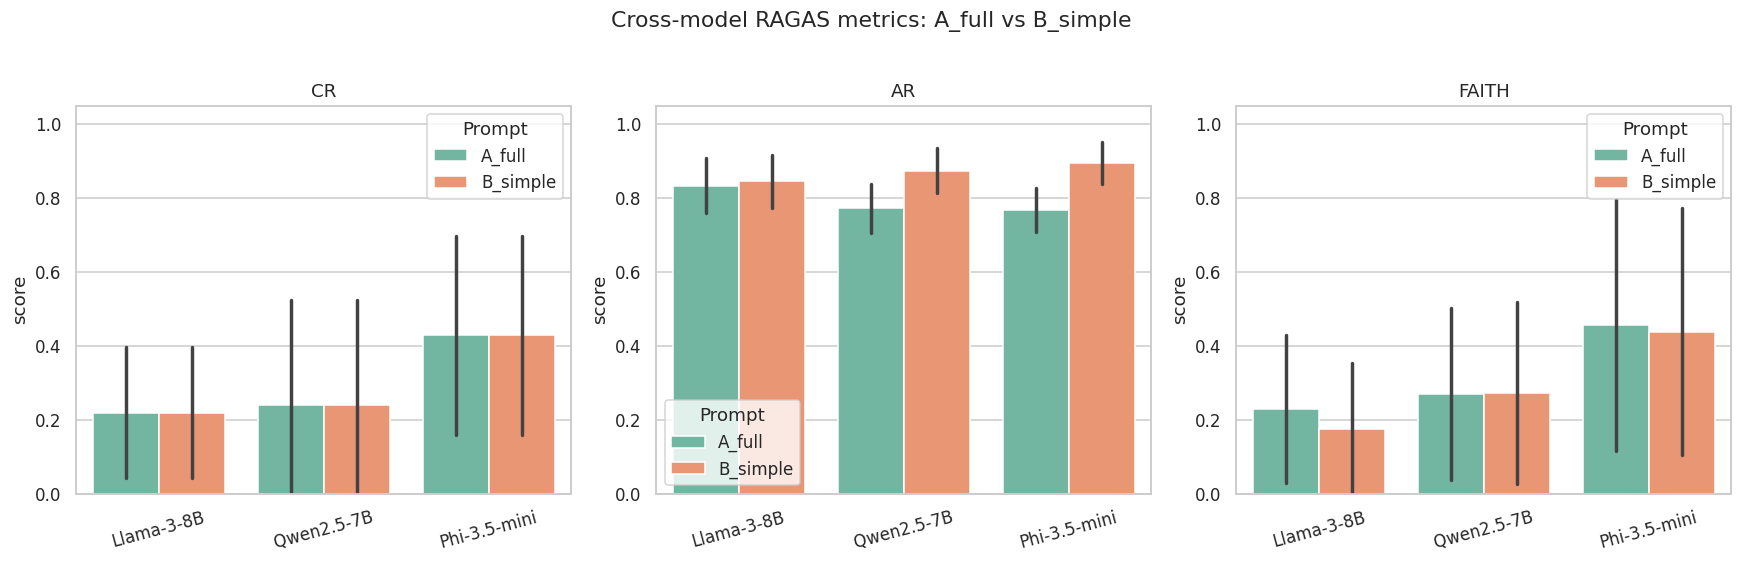

跨模型对比图已保存


In [36]:
if 'df_all_models' in dir() and len(df_all_models) > 0:
    metrics_cols = ["manual_cr","manual_ar","manual_faith"]
    melt = df_all_models.melt(
        id_vars=["qid","prompt_version","model"],
        value_vars=metrics_cols,
        var_name="metric", value_name="score"
    )
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, metric in zip(axes, metrics_cols):
        data = melt[melt.metric == metric]
        sns.barplot(data=data, x="model", y="score", hue="prompt_version",
                    ax=ax, palette="Set2", ci="sd")
        ax.set_title(metric.replace("manual_","").upper())
        ax.set_ylim(0, 1.05)
        ax.set_xlabel(""); ax.tick_params(axis='x', rotation=15)
        ax.legend(title="Prompt")
    fig.suptitle("Cross-model RAGAS metrics: A_full vs B_simple", y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig_11_1_cross_model.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("跨模型对比图已保存")

### 11.2 A vs B — 平均指标对比

Aggregating over 3 model(s) x 20 queries x 2 prompts = 120 data points

               lib_cr        manual_cr        lib_ar        manual_ar         \
                 mean    std      mean    std   mean    std      mean    std   
prompt_version                                                                 
A_full          0.872  0.281     0.293  0.261  0.705  0.230     0.792  0.073   
B_simple        0.862  0.297     0.293  0.261  0.831  0.129     0.871  0.065   

               lib_faith        manual_faith         
                    mean    std         mean    std  
prompt_version                                       
A_full             0.253  0.278        0.328  0.283  
B_simple           0.249  0.302        0.306  0.284  


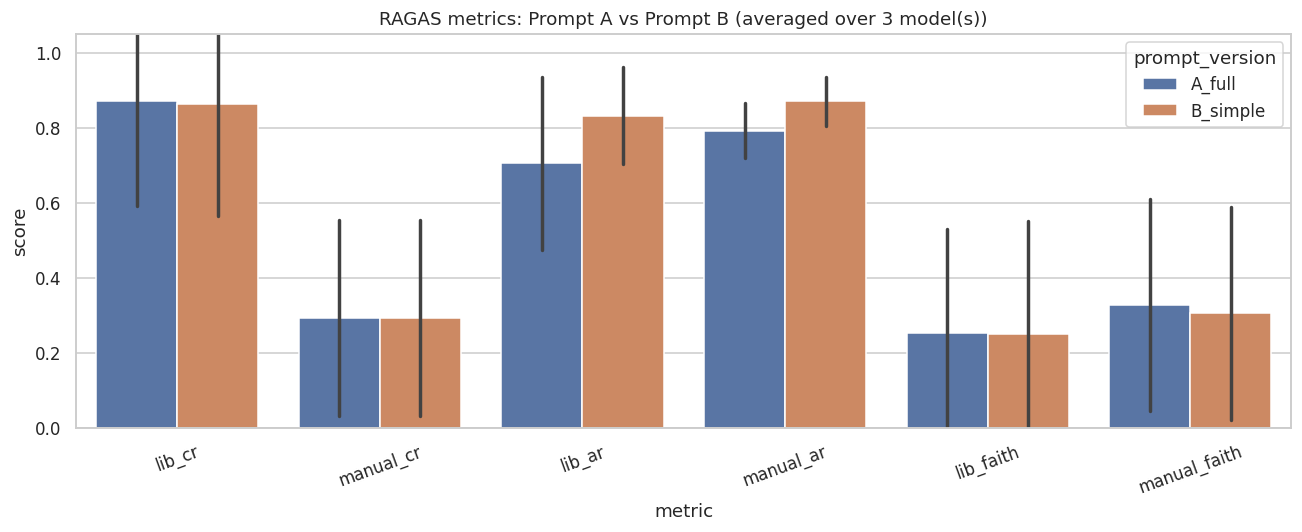

In [37]:
# §11.2 — A vs B 平均对比，**聚合全部 3 个模型**（每条 query 3 个数据点）
# 之前误用 df_eval（仅最后一个模型）→ A vs B 差异被单模型噪声主导。
src_df = df_all_models if 'df_all_models' in dir() and len(df_all_models) > 0 else df_eval

metrics_cols = ["lib_cr","manual_cr","lib_ar","manual_ar","lib_faith","manual_faith"]
metrics_cols = [c for c in metrics_cols if c in src_df.columns]

n_models = src_df["model"].nunique() if "model" in src_df.columns else 1
print(f"Aggregating over {n_models} model(s) x {src_df['qid'].nunique()} queries x 2 prompts "
      f"= {len(src_df)} data points\n")

agg = src_df.groupby("prompt_version")[metrics_cols].agg(["mean","std"])
print(agg.round(3))

melt = src_df.melt(id_vars=["qid","prompt_version"] + (["model"] if "model" in src_df.columns else []),
                   value_vars=metrics_cols, var_name="metric", value_name="score")
plt.figure(figsize=(12, 5))
sns.barplot(data=melt, x="metric", y="score", hue="prompt_version", errorbar="sd")
plt.xticks(rotation=20); plt.ylim(0, 1.05)
plt.title(f"RAGAS metrics: Prompt A vs Prompt B (averaged over {n_models} model(s))")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_11_2_a_vs_b_avg.png", dpi=150, bbox_inches="tight")
plt.show()

### 11.3 每条查询的指标热力图

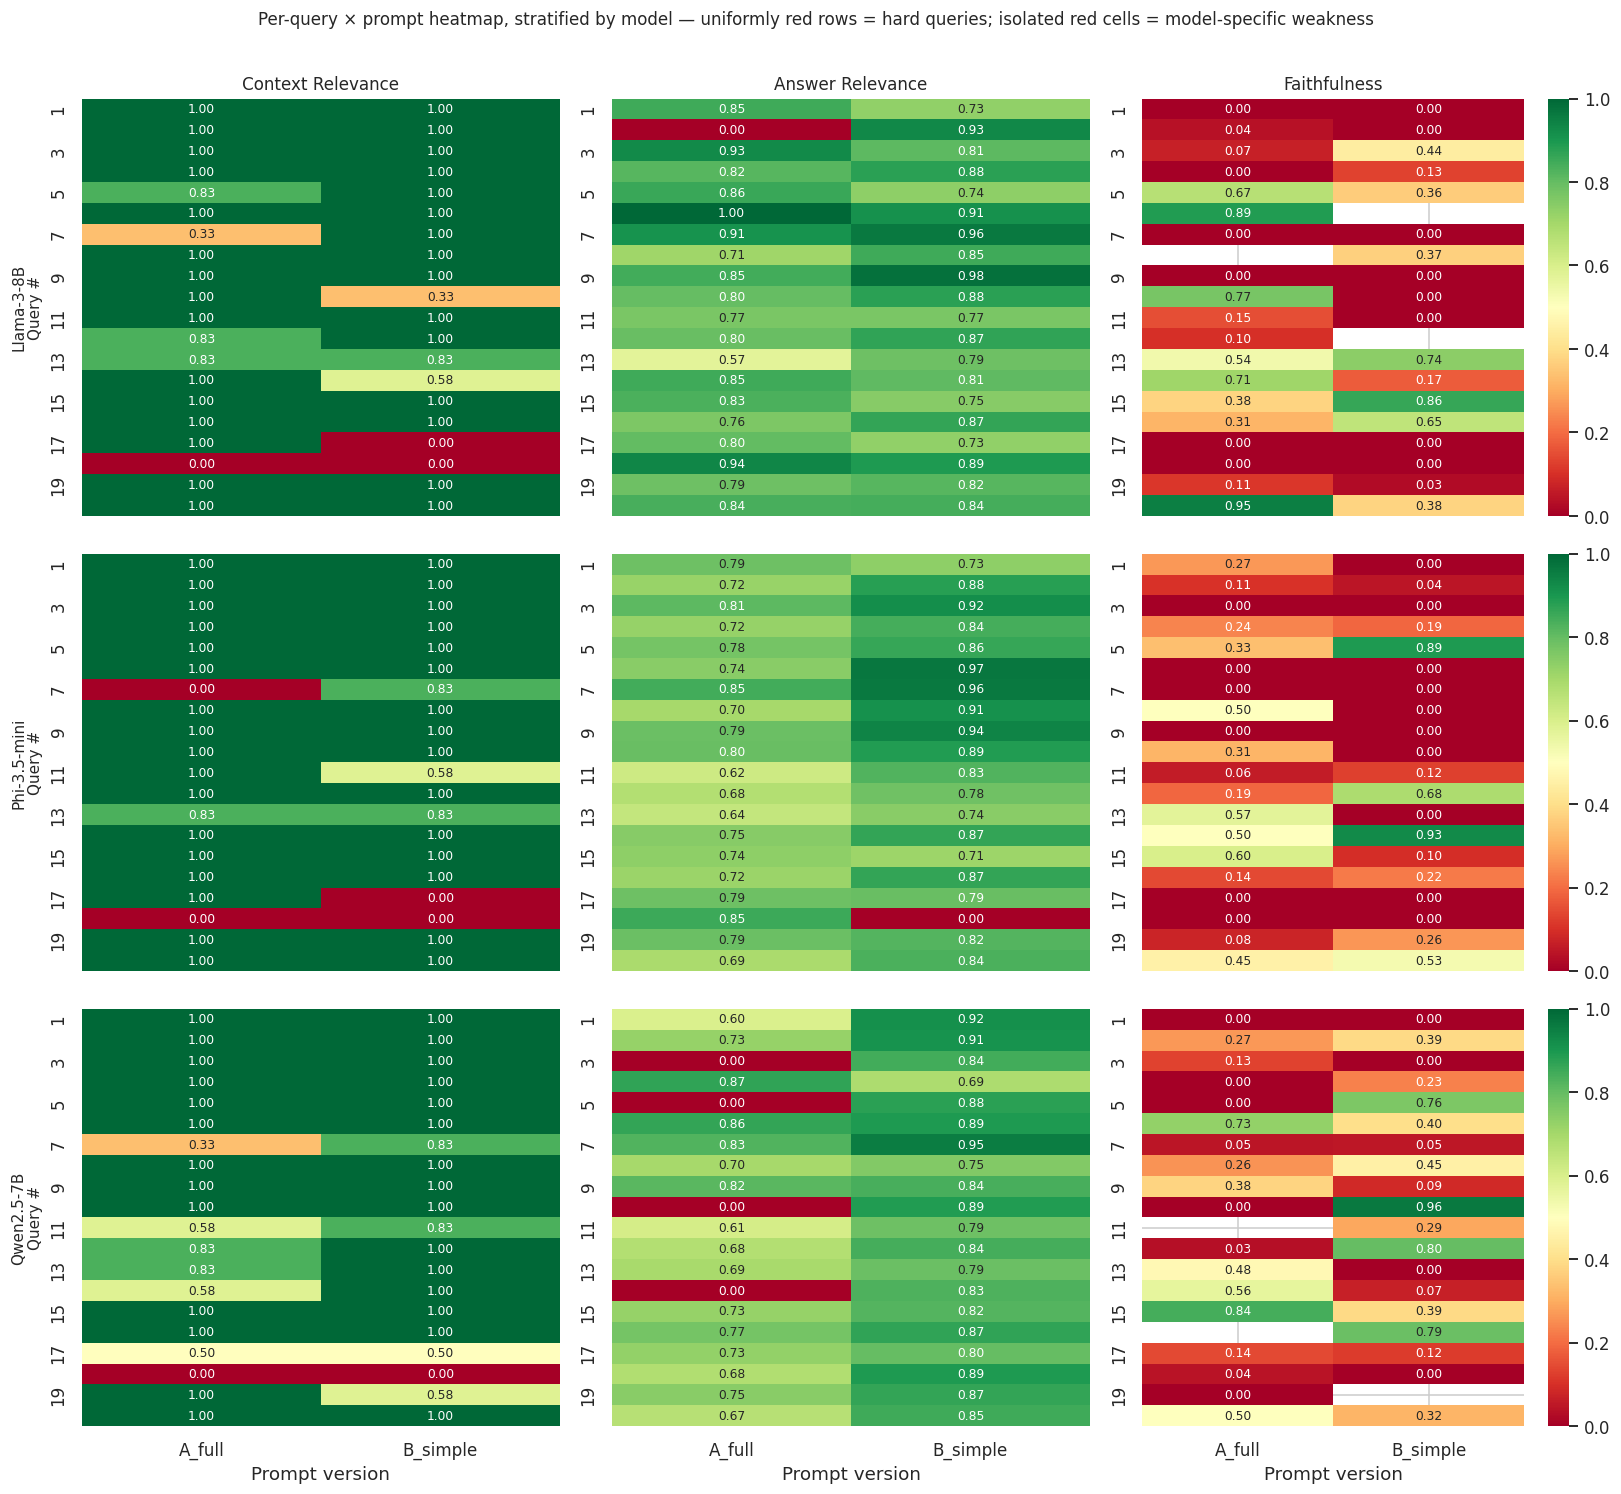

In [38]:
# §11.3 — Per-query metrics heatmap, one row per model (3-model grid).
# Reveals: which queries are uniformly hard (low across all models)
# vs which expose model-specific weakness (low only for one model).
src_df = df_all_models if 'df_all_models' in dir() and len(df_all_models) > 0 else df_eval

models_sorted = sorted(src_df["model"].dropna().unique())
n_models = len(models_sorted)
metrics_cols = ["lib_cr", "lib_ar", "lib_faith"]
metric_titles = ["Context Relevance", "Answer Relevance", "Faithfulness"]

fig, axes = plt.subplots(n_models, 3, figsize=(15, 4.5 * n_models),
                         squeeze=False, sharex="col")
for row_idx, model in enumerate(models_sorted):
    sub = src_df[src_df.model == model]
    pivot_all = sub.pivot_table(index="qid", columns="prompt_version",
                                 values=metrics_cols)
    for col_idx, (metric, title) in enumerate(zip(metrics_cols, metric_titles)):
        ax = axes[row_idx, col_idx]
        if metric not in pivot_all.columns.get_level_values(0):
            ax.text(0.5, 0.5, "no data", ha="center", transform=ax.transAxes)
            continue
        data = pivot_all[metric]
        sns.heatmap(data, annot=True, fmt=".2f", cmap="RdYlGn",
                    vmin=0, vmax=1, ax=ax, cbar=col_idx == 2,
                    annot_kws={"size": 8})
        if row_idx == 0:
            ax.set_title(title, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{model}\nQuery #", fontsize=10)
        else:
            ax.set_ylabel("")
        ax.set_xlabel("" if row_idx < n_models - 1 else "Prompt version")

plt.suptitle("Per-query × prompt heatmap, stratified by model — "
             "uniformly red rows = hard queries; isolated red cells = model-specific weakness",
             y=1.005, fontsize=11)
plt.tight_layout(); plt.savefig(FIG_DIR / "fig_11_3_heatmap_by_model.png", dpi=150, bbox_inches="tight"); plt.show()

### 11.4 检索质量评估可视化

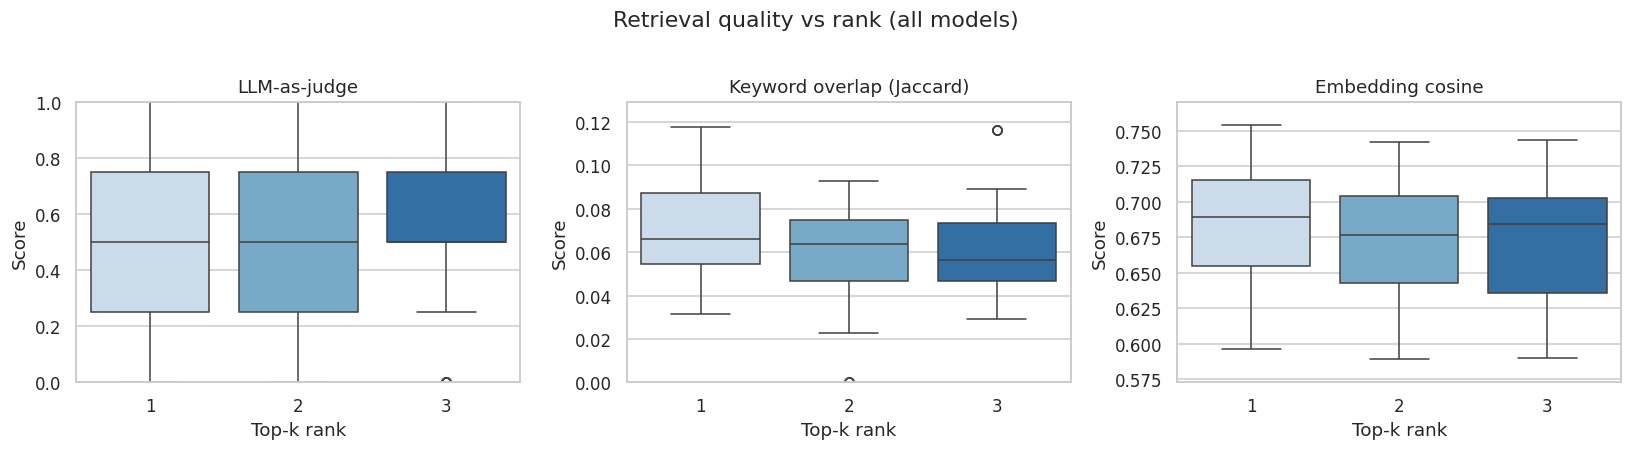

In [39]:
# 加载检索评估结果
ret_dfs = []
for model_name in LLM_CANDIDATES:
    tag = model_tag(model_name)
    csv_path = DATA_DIR / f"retrieval_eval_{tag}.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        ret_dfs.append(df)

if ret_dfs:
    df_ret_all = pd.concat(ret_dfs, ignore_index=True)
    df_ret = df_ret_all  # 默认用合并结果

    fig1, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col, title in zip(
        axes,
        ["llm_score", "kw_overlap", "emb_sim"],
        ["LLM-as-judge", "Keyword overlap (Jaccard)", "Embedding cosine"]
    ):
        sns.boxplot(data=df_ret, x="rank", y=col, ax=ax, palette="Blues")
        ax.set_title(title)
        ax.set_xlabel("Top-k rank"); ax.set_ylabel("Score")
        col_min, col_max = df_ret[col].min(), df_ret[col].max()
        margin = (col_max - col_min) * 0.1
        ax.set_ylim(max(0, col_min - margin), min(1, col_max + margin))

    fig1.suptitle("Retrieval quality vs rank (all models)", y=1.02)
    fig1.tight_layout()
    fig1.savefig(FIG_DIR / "fig_11_4_retrieval_quality.png", dpi=150, bbox_inches="tight")
    plt.show()

### 11.4b Retriever ablation — Dense vs Sparse vs Hybrid RRF

Why bother with hybrid retrieval? Pick two queries with **different lexical/semantic profiles** and run the three retrievers separately:

- **Dense (BGE + FAISS)** — semantic similarity; handles paraphrase well, misses rare/exact tokens (CVE numbers, technique IDs).
- **Sparse (BM25)** — exact-token matching; handles `T1059.001` and `CVE-2024-3400` precisely, fails on synonyms.
- **Hybrid (RRF)** — fuses both rank lists; should recover what each individual retriever misses.

The table below shows the top-3 chunks each retriever returns. Look for cases where Dense and Sparse disagree but Hybrid picks up something both would have missed — that is the value-add of fusion.

In [40]:
# Ablation: same query, three retrievers. Pick 2 queries with different profiles.
ABLATION_QUERIES = {
    "Semantic-heavy (paraphrase)":
        "How should a small startup with an Azure tenant secure privileged accounts "
        "against password-spray and token theft attacks?",
    "Lexical-heavy (exact IDs)":
        "Given CISA KEV entries around Citrix NetScaler (CVE-2023-4966) and PAN-OS "
        "(CVE-2024-3400), what is a prioritized remediation plan?",
}

def _top3_table(query, retriever_name, hits):
    return pd.DataFrame([
        {"retriever": retriever_name, "rank": r + 1,
         "chunk_id": h["chunk_id"] if isinstance(h, dict) else h[0],
         "source":   all_chunks[h["chunk_id"] if isinstance(h, dict) else h[0]]["source"],
         "title":    all_chunks[h["chunk_id"] if isinstance(h, dict) else h[0]]["title"][:60]}
        for r, h in enumerate(hits[:3])
    ])

for label, q in ABLATION_QUERIES.items():
    print("=" * 80)
    print(f"[{label}]")
    print(f"  Query: {q[:90]}..." if len(q) > 90 else f"  Query: {q}")
    print("=" * 80)

    d_hits  = dense_search(q, k=3)
    s_hits  = sparse_search(q, k=3)
    h_hits  = rrf_hybrid_search(q, top_k=3)

    d_ids = {h[0] for h in d_hits[:3]}
    s_ids = {h[0] for h in s_hits[:3]}
    h_ids = {h["chunk_id"] for h in h_hits[:3]}

    print(f"  Dense top-3 chunk_ids : {sorted(d_ids)}")
    print(f"  Sparse top-3 chunk_ids: {sorted(s_ids)}")
    print(f"  Hybrid top-3 chunk_ids: {sorted(h_ids)}")
    overlap_ds = len(d_ids & s_ids)
    print(f"  Dense ∩ Sparse: {overlap_ds}/3 chunks agree "
          f"(low overlap = retrievers see different things → fusion pays off)")
    h_only = h_ids - (d_ids | s_ids)
    if h_only:
        print(f"  ⚠ Hybrid picked {len(h_only)} chunk(s) absent from BOTH single retrievers "
              f"(promoted by joint rank): {sorted(h_only)}")

    combined = pd.concat([
        _top3_table(q, "Dense",  d_hits),
        _top3_table(q, "Sparse", s_hits),
        _top3_table(q, "Hybrid", h_hits),
    ], ignore_index=True)
    print(combined.to_string(index=False))
    print()

# Aggregate Jaccard across all 20 practitioner queries — quantitative summary
print("=" * 80)
print("Aggregate retriever agreement over all 20 PRACTITIONER_QUERIES (Jaccard @ top-3)")
print("=" * 80)
jacc_ds, jacc_dh, jacc_sh = [], [], []
for q in PRACTITIONER_QUERIES:
    d = {h[0] for h in dense_search(q, k=3)[:3]}
    s = {h[0] for h in sparse_search(q, k=3)[:3]}
    hy = {h["chunk_id"] for h in rrf_hybrid_search(q, top_k=3)[:3]}
    def jac(a, b): return len(a & b) / max(1, len(a | b))
    jacc_ds.append(jac(d, s)); jacc_dh.append(jac(d, hy)); jacc_sh.append(jac(s, hy))

print(f"  Dense vs Sparse   Jaccard: mean = {np.mean(jacc_ds):.3f}  "
      f"(low → they disagree, hybrid has room to add value)")
print(f"  Dense vs Hybrid   Jaccard: mean = {np.mean(jacc_dh):.3f}  "
      f"(how often Hybrid keeps Dense's picks)")
print(f"  Sparse vs Hybrid  Jaccard: mean = {np.mean(jacc_sh):.3f}  "
      f"(how often Hybrid keeps Sparse's picks)")

[Semantic-heavy (paraphrase)]
  Query: How should a small startup with an Azure tenant secure privileged accounts against passwor...
  Dense top-3 chunk_ids : [3335, 3336, 3337]
  Sparse top-3 chunk_ids: [5193, 5685, 12609]
  Hybrid top-3 chunk_ids: [3336, 3337, 12609]
  Dense ∩ Sparse: 0/3 chunks agree (low overlap = retrievers see different things → fusion pays off)
retriever  rank  chunk_id                  source                                                        title
    Dense     1      3336            MITRE ATT&CK           T1528 Steal Application Access Token (description)
    Dense     2      3337            MITRE ATT&CK           T1528 Steal Application Access Token (description)
    Dense     3      3335            MITRE ATT&CK           T1528 Steal Application Access Token (description)
   Sparse     1     12609 Rowden CybersecurityQAA CyQA [Authentication User Access and Controls]: What should 
   Sparse     2      5685            MITRE ATT&CK                       T1

### 11.5 手动 vs RAGAS 库实现的一致性

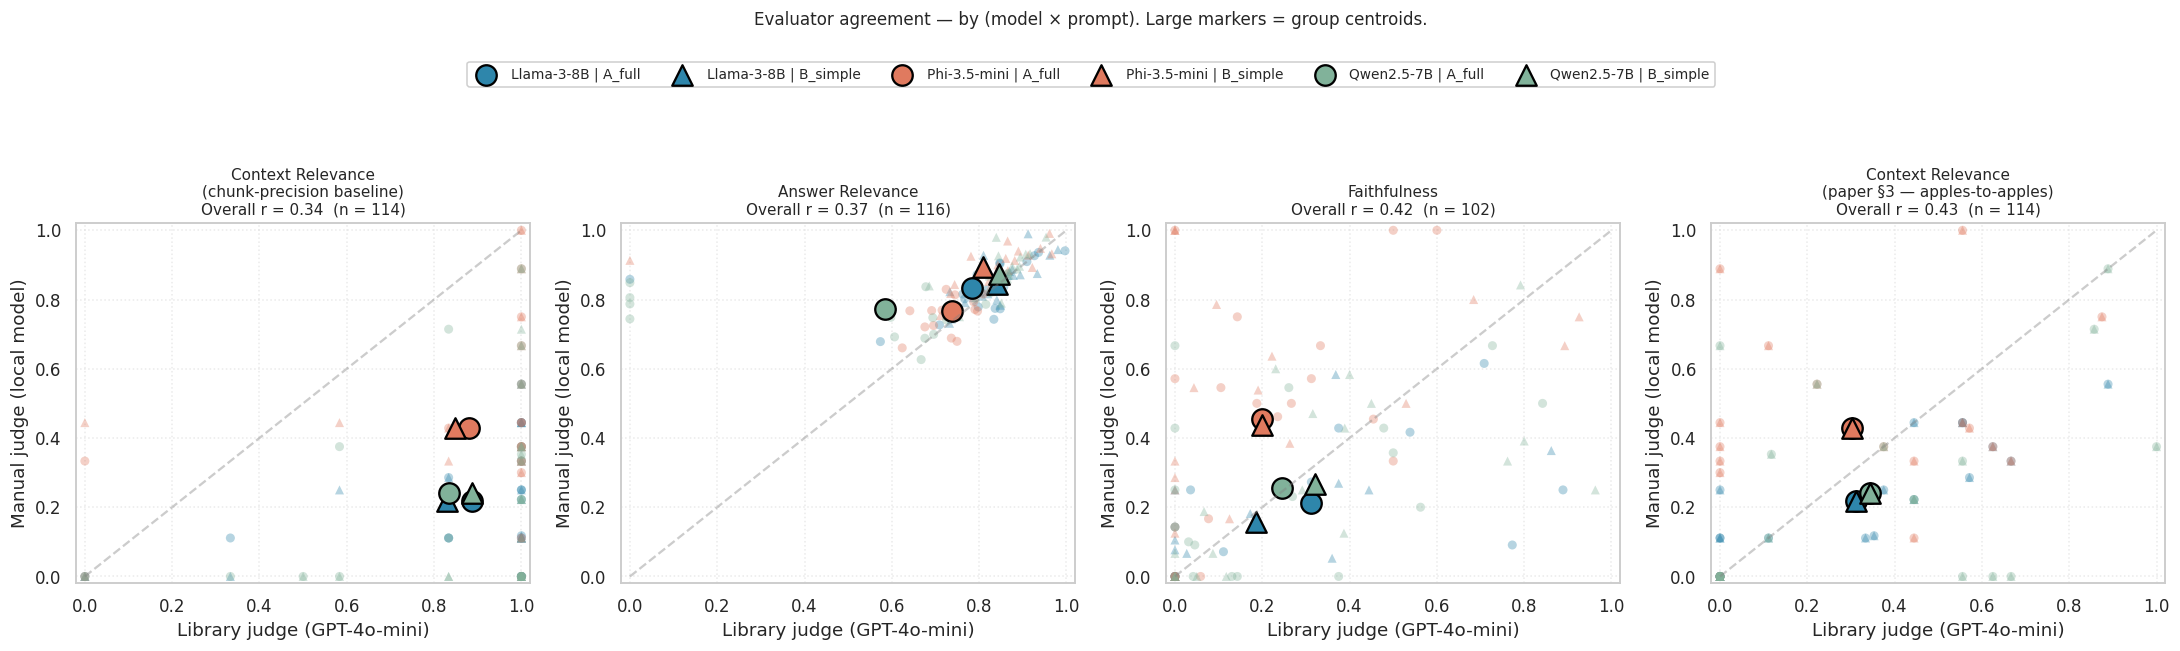

In [41]:
# 11.5 — Manual (local-model judge) vs Library (GPT-4o-mini judge)
# 编码：color = 模型，marker = prompt 版本，大号实心标记 = 该组 centroid
# 第 4 个子图：manual_cr vs lib_cr_paper（算法对齐到论文 §3 句子级，apples-to-apples）
from scipy.stats import pearsonr

# 用全模型数据
src_df = df_all_models if "df_all_models" in dir() and len(df_all_models) > 0 else df_eval

# 4 组对：前 3 个是现有的；第 4 个用新算法对齐的 CR
pairs = [("lib_cr",       "manual_cr",    "Context Relevance\n(chunk-precision baseline)"),
         ("lib_ar",       "manual_ar",    "Answer Relevance"),
         ("lib_faith",    "manual_faith", "Faithfulness"),
         ("lib_cr_paper", "manual_cr",    "Context Relevance\n(paper §3 — apples-to-apples)")]

# 是否有 lib_cr_paper 列
has_cr_paper = "lib_cr_paper" in src_df.columns
n_panels = 4 if has_cr_paper else 3

fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5))
if n_panels == 1: axes = [axes]

model_palette = ["#2E86AB", "#E07A5F", "#81B29A", "#9B5DE5"]
models_sorted = sorted(src_df["model"].dropna().unique())
model_colors = dict(zip(models_sorted, model_palette[:len(models_sorted)]))
prompt_markers = {"A_full": "o", "B_simple": "^"}

for ax_idx, (lib, man, title) in enumerate(pairs[:n_panels]):
    ax = axes[ax_idx]
    if lib not in src_df.columns:
        ax.text(0.5, 0.5, f"{lib}\n(not computed)", ha="center", va="center",
                transform=ax.transAxes, fontsize=10, color="gray")
        ax.set_title(title); continue

    sub = src_df[[lib, man, "prompt_version", "model"]].dropna(subset=[lib, man])
    if len(sub) < 2:
        ax.text(0.5, 0.5, "n<2 (too many NaN)", ha="center", transform=ax.transAxes)
        ax.set_title(title); continue

    # 单点散布（半透明）
    for model in models_sorted:
        for prompt, marker in prompt_markers.items():
            mask = (sub["model"] == model) & (sub["prompt_version"] == prompt)
            if mask.sum():
                ax.scatter(sub.loc[mask, lib], sub.loc[mask, man],
                           c=model_colors[model], marker=marker, alpha=0.35,
                           s=35, edgecolor="none")

    # 每组 centroid（大号实心，黑边）
    legend_handles = []
    for model in models_sorted:
        for prompt, marker in prompt_markers.items():
            mask = (sub["model"] == model) & (sub["prompt_version"] == prompt)
            if mask.sum():
                cx = sub.loc[mask, lib].mean()
                cy = sub.loc[mask, man].mean()
                h = ax.scatter([cx], [cy], c=model_colors[model], marker=marker,
                               s=180, edgecolor="black", linewidth=1.5,
                               label=f"{model} | {prompt}")
                legend_handles.append(h)

    ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.4)
    r, pval = pearsonr(sub[lib], sub[man])
    ax.set_title(f"{title}\nOverall r = {r:.2f}  (n = {len(sub)})", fontsize=10)
    ax.set_xlabel("Library judge (GPT-4o-mini)")
    ax.set_ylabel("Manual judge (local model)")
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.grid(True, linestyle=":", alpha=0.4)

# 单一图例放图外顶部 —— 4 个子图共用，避免每图重复
handles, labels = axes[0].get_legend_handles_labels() if hasattr(axes, "__len__") else axes.get_legend_handles_labels()
if not handles:
    # 第一个 axis 可能没数据，向后找一个有 legend handles 的
    for ax in (axes if hasattr(axes, "__len__") else [axes]):
        h, l = ax.get_legend_handles_labels()
        if h:
            handles, labels = h, l
            break
if handles:
    fig.legend(handles=handles, labels=labels, loc="upper center",
               bbox_to_anchor=(0.5, 1.10), ncol=min(len(handles), 6),
               fontsize=9, frameon=True, framealpha=0.95)

plt.suptitle("Evaluator agreement — by (model × prompt). Large markers = group centroids.",
             y=1.18, fontsize=11)
plt.tight_layout(); plt.savefig(FIG_DIR / "fig_11_5_evaluator_agreement.png", dpi=150, bbox_inches="tight"); plt.show()

**怎么读这三张图**

- **对角线附近 + r > 0.7**：两套裁判达成共识，说明该指标在本场景下稳健，结论可信。
- **点系统性偏在对角线左上方（manual > lib）**：本地模型给自己打分偏高 —— self-preference bias 的实证证据。
- **点系统性偏在对角线右下方（lib > manual）**：本地模型识别能力不如 GPT-4o-mini 强，把好答案错判为差。
- **r 接近 0 / 散点云团**：两套裁判判断逻辑差异大，单独看哪一个都不可信，需要进一步核查。

下方 `abs_diff_mean` 给出两套裁判分数的平均**绝对**差值 —— 不论方向，差值越大说明评估方法的选择对结论影响越大，这是 RAG 系统 trustworthiness 讨论必须正视的一层不确定性。

### 11.5b 数字化拆解：(模型 × prompt) 的均值与 A−B 差距

散点图看视觉趋势，下面这张表把它翻译成具体数字：
- 每行 = 一个 (model × prompt × metric) 组合的均值
- **A−B gap** 列：正值表示 Prompt A 比 B 强（结构化引用约束的边际收益）
- 跨模型读：同一指标下哪个模型综合最高 / 最低，给出模型选择的实证依据

In [42]:
# 每个 (model × prompt) 的指标均值
src_df = df_all_models if 'df_all_models' in dir() and len(df_all_models) > 0 else df_eval
metric_cols = [c for c in ["manual_cr","manual_ar","manual_faith",
                              "lib_cr","lib_ar","lib_faith","lib_cr_paper"]
                if c in src_df.columns]

summary = (src_df.groupby(["model","prompt_version"])[metric_cols]
                  .mean().round(3))
print("="*78)
print("(model × prompt) 均值表")
print("="*78)
print(summary)

# A_full − B_simple gap per (model, metric)
print("\n"+"="*78)
print("A_full − B_simple gap（正值 = A 比 B 强）")
print("="*78)
gap_rows = []
for model in sorted(src_df["model"].dropna().unique()):
    sub = src_df[src_df["model"] == model]
    a = sub[sub.prompt_version=="A_full"][metric_cols].mean()
    b = sub[sub.prompt_version=="B_simple"][metric_cols].mean()
    gap_rows.append((model, (a - b).round(3)))
gap_df = pd.DataFrame({m: g for m, g in gap_rows}).T
gap_df.index.name = "model"
print(gap_df)

# 跨模型对比：每个指标的模型排名
print("\n"+"="*78)
print("跨模型排名（每个指标按 A_full 均值降序）")
print("="*78)
a_only = src_df[src_df.prompt_version=="A_full"].groupby("model")[metric_cols].mean().round(3)
for col in metric_cols:
    if col in a_only.columns:
        ranking = a_only[col].sort_values(ascending=False)
        print(f"  {col:18s}  {' > '.join(f'{m} ({v:.3f})' for m, v in ranking.items())}")

(model × prompt) 均值表
                             manual_cr  manual_ar  manual_faith  lib_cr  \
model        prompt_version                                               
Llama-3-8B   A_full              0.219      0.833         0.229   0.892   
             B_simple            0.219      0.845         0.175   0.837   
Phi-3.5-mini A_full              0.429      0.767         0.456   0.892   
             B_simple            0.429      0.894         0.438   0.862   
Qwen2.5-7B   A_full              0.241      0.772         0.270   0.833   
             B_simple            0.241      0.874         0.271   0.887   

                             lib_ar  lib_faith  lib_cr_paper  
model        prompt_version                                   
Llama-3-8B   A_full           0.783      0.299         0.340  
             B_simple         0.840      0.230         0.340  
Phi-3.5-mini A_full           0.748      0.217         0.323  
             B_simple         0.808      0.199         0.323  


### 11.5c Statistical significance — Paired t-test on A vs B (per model)

Means in §11.5b show direction; this cell tells you whether the A−B gap is statistically real or within noise. 20 queries × 3 models × paired (same qid for A and B) → 60 paired comparisons per metric.

- `p < 0.05` ★ : A vs B difference is unlikely to be noise
- `p < 0.01` ★★: strong evidence A vs B differ
- `p ≥ 0.05`  : not significant — diff is within noise

In [43]:
# Paired t-test: A_full vs B_simple, per (model, metric)
from scipy.stats import ttest_rel

src_df = df_all_models if 'df_all_models' in dir() and len(df_all_models) > 0 else df_eval
metric_cols = [c for c in ["manual_cr","manual_ar","manual_faith",
                              "lib_cr","lib_ar","lib_faith","lib_cr_paper"]
                if c in src_df.columns]

rows = []
for model in sorted(src_df["model"].dropna().unique()):
    sub = src_df[src_df.model == model]
    for metric in metric_cols:
        a = sub[sub.prompt_version=="A_full"].set_index("qid")[metric]
        b = sub[sub.prompt_version=="B_simple"].set_index("qid")[metric]
        common_qids = a.index.intersection(b.index)
        a, b = a.loc[common_qids], b.loc[common_qids]
        # paired t-test, drop NaN pairs
        pair_df = pd.DataFrame({"a": a, "b": b}).dropna()
        if len(pair_df) < 3:
            rows.append({"model": model, "metric": metric, "n": len(pair_df),
                         "mean_A": float('nan'), "mean_B": float('nan'),
                         "diff": float('nan'), "p_value": float('nan'), "sig": "n/a"})
            continue
        t_stat, p_val = ttest_rel(pair_df["a"], pair_df["b"])
        sig = "★★" if p_val < 0.01 else ("★ " if p_val < 0.05 else "  ")
        rows.append({"model": model, "metric": metric, "n": len(pair_df),
                     "mean_A": round(pair_df["a"].mean(), 3),
                     "mean_B": round(pair_df["b"].mean(), 3),
                     "diff":   round(pair_df["a"].mean() - pair_df["b"].mean(), 3),
                     "p_value": round(p_val, 4), "sig": sig})

ttest_df = pd.DataFrame(rows)
print("Paired t-test: A_full vs B_simple (per model × metric)")
print("=" * 78)
print(ttest_df.to_string(index=False))
print("\n★ = p<0.05, ★★ = p<0.01")

Paired t-test: A_full vs B_simple (per model × metric)
       model       metric  n  mean_A  mean_B   diff  p_value sig
  Llama-3-8B    manual_cr 19   0.219   0.219  0.000      NaN    
  Llama-3-8B    manual_ar 20   0.833   0.845 -0.012   0.3654    
  Llama-3-8B manual_faith  9   0.227   0.181  0.046   0.3991    
  Llama-3-8B       lib_cr 20   0.892   0.837  0.054   0.4708    
  Llama-3-8B       lib_ar 20   0.783   0.840 -0.057   0.2741    
  Llama-3-8B    lib_faith 17   0.276   0.221  0.054   0.5184    
  Llama-3-8B lib_cr_paper 20   0.340   0.340  0.000      NaN    
Phi-3.5-mini    manual_cr 18   0.429   0.429  0.000      NaN    
Phi-3.5-mini    manual_ar 16   0.767   0.886 -0.119   0.0000  ★★
Phi-3.5-mini manual_faith 19   0.456   0.461 -0.005   0.9342    
Phi-3.5-mini       lib_cr 20   0.892   0.862  0.029   0.6807    
Phi-3.5-mini       lib_ar 20   0.748   0.808 -0.060   0.2508    
Phi-3.5-mini    lib_faith 20   0.217   0.199  0.019   0.7887    
Phi-3.5-mini lib_cr_paper 20   0.32

### 11.6 每条查询 Top-3 来源分布

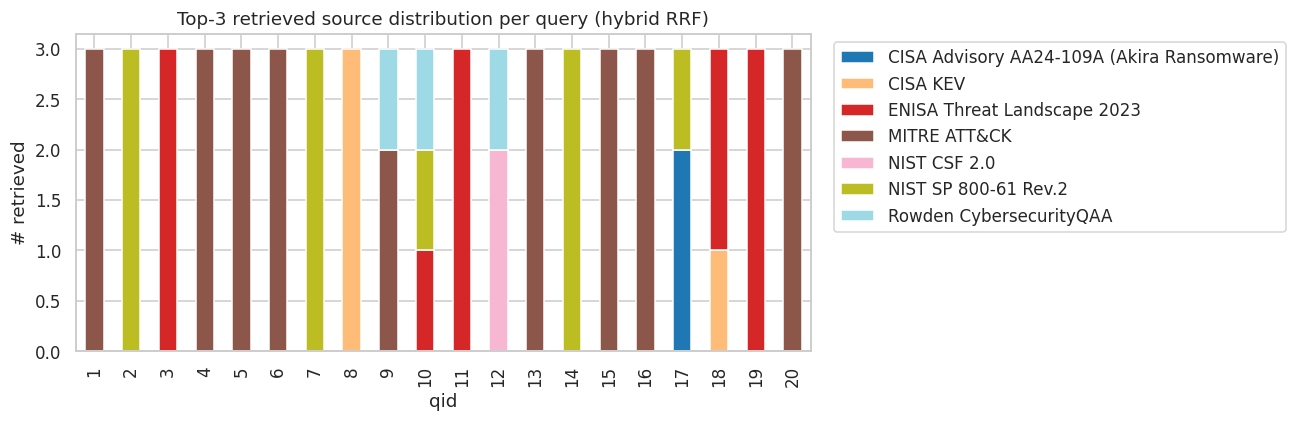

In [44]:
src_rows = []
for rec in records_A:
    for h in rec["hits"]:
        src_rows.append({"qid": rec["qid"], "source": h["source"]})
df_src = pd.DataFrame(src_rows)
pivot_src = df_src.pivot_table(index="qid", columns="source", aggfunc=len, fill_value=0)
pivot_src.plot(kind="bar", stacked=True, figsize=(12,4),
               colormap="tab20")
plt.title("Top-3 retrieved source distribution per query (hybrid RRF)")
plt.ylabel("# retrieved"); plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig_11_6_top3_source_dist.png", dpi=150, bbox_inches="tight"); plt.show()


### 11.7 Faithfulness 深挖 — 不被支持的 claim

In [45]:
# §11.7 — Load faithfulness verdicts from ALL available models, not just the first.
# 每条 raw 记录带 model 字段，下游分析按模型分组。
manual_faith_raw = []
df_faith_per_model = []
for model_name in LLM_CANDIDATES:
    tag = model_tag(model_name)
    pkl_path = DATA_DIR / f"manual_eval_{tag}.pkl"
    if not pkl_path.exists():
        print(f"⚠ {model_name}: {pkl_path.name} 不存在，跳过")
        continue
    with open(pkl_path, "rb") as f:
        saved = pickle.load(f)
    raw = saved.get("faith_raw", []) or []
    for r in raw:
        r["model"] = model_name
        manual_faith_raw.append(r)
    df_one = saved.get("df_manual_faith", pd.DataFrame())
    if len(df_one):
        df_one = df_one.copy()
        df_one["model"] = model_name
        df_faith_per_model.append(df_one)
    print(f"✓ {model_name}: {len(raw)} faith records")

if df_faith_per_model:
    df_faith_loaded = pd.concat(df_faith_per_model, ignore_index=True)
    n_models = df_faith_loaded["model"].nunique()
    print(f"\nTotal: {len(manual_faith_raw)} verdicts across {n_models} model(s)")
else:
    df_faith_loaded = pd.DataFrame()
    print("⚠ 未找到任何 faithfulness verdicts 数据")

✓ Llama-3-8B: 40 faith records
✓ Qwen2.5-7B: 40 faith records
✓ Phi-3.5-mini: 40 faith records

Total: 120 verdicts across 3 model(s)


A_full: unsupported claims per model
              n_unsupported  n_verify_failed (dropped)
model                                                 
Llama-3-8B              112                          0
Phi-3.5-mini             62                         20
Qwen2.5-7B              192                          0

Per-(qid × model) unsupported-claim count [A_full]
model  Llama-3-8B  Phi-3.5-mini  Qwen2.5-7B
qid                                        
1              12             3           6
2               6             5          10
3               0             3          16
4               0             7           3
5               0             3          12
6               6             4           4
7              15             4          10
8               5             0           5
9               0             0          17
10             10             3           8
11              0             6           6
12              0             1          18
13              7   

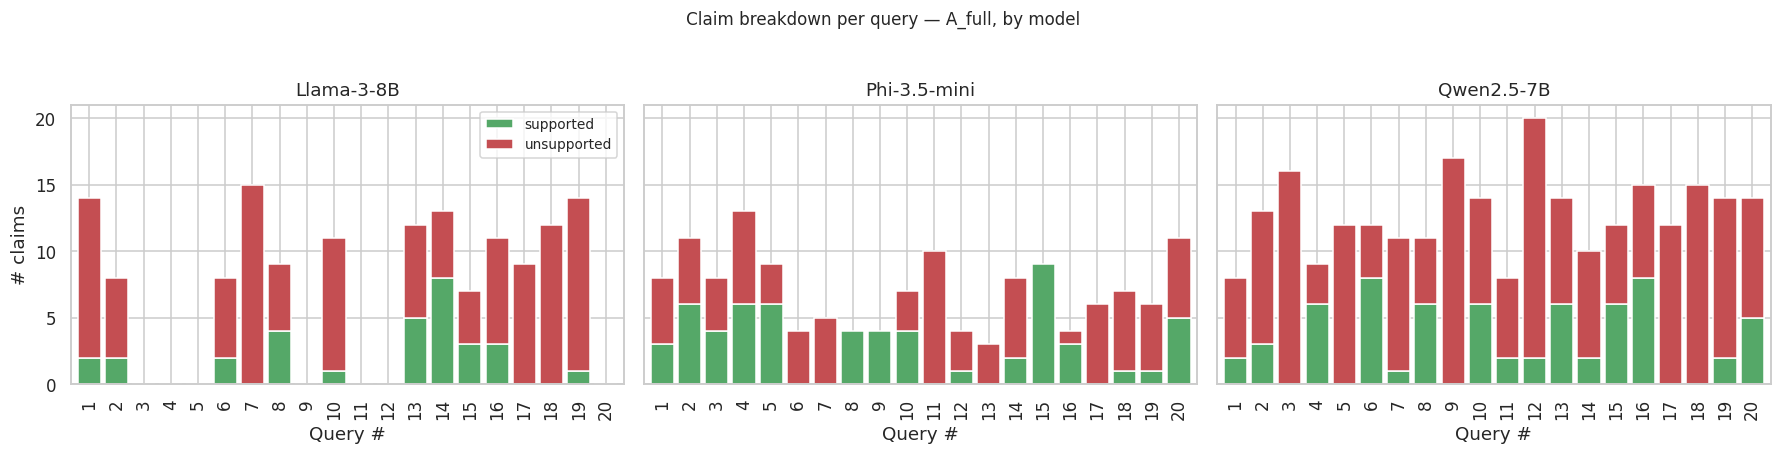


Example deep-dive: Q1 (unsupported across ALL models)

[Llama-3-8B]
  claim: Verify the alert and gather additional context.
  why:   The context discusses various scenarios of malicious file execution, including file downloads and opens, but does not me...

[Llama-3-8B]
  claim: Confirm the alert is legitimate and gather more information about the incident.
  why:   The context discusses various malicious file execution scenarios, including file downloads and opens, but does not menti...

[Llama-3-8B]
  claim: Gather information about the affected system, user, and time of occurrence.
  why:   The context discusses various malicious file execution scenarios, including download/open, spawn chain, and PowerShell a...

[Llama-3-8B]
  claim: Review the EDR system's alert details, check the system's logs, and consult with the user who reported the incident.
  why:   The context discusses various malicious file execution scenarios, including download/open, spawn chain, and PowerShell a...


In [46]:
# §11.7 — Cross-model unsupported claim analysis (A_full only).
# 注意 verdict 字段：Opt 1 起从 "reason" 改为 "explanation"，supported==None 是 verify 调用失败。

unsupported_rows = []
n_verify_failed = {}
for row in manual_faith_raw:
    if row.get("prompt_version") != "A_full": continue
    model = row.get("model", "?")
    n_verify_failed.setdefault(model, 0)
    for v in row.get("verdicts", []):
        sup = v.get("supported")
        if sup is None:
            n_verify_failed[model] += 1
            continue
        if sup is False:
            unsupported_rows.append({
                "model": model,
                "qid": row["qid"],
                "claim": v.get("claim", ""),
                "explanation": v.get("explanation") or v.get("reason") or "",
            })
df_unsup = pd.DataFrame(unsupported_rows)

# 1. 按模型 unsupported / verify-failed 计数
print("=" * 70)
print("A_full: unsupported claims per model")
print("=" * 70)
if len(df_unsup) > 0:
    summary = df_unsup.groupby("model").size().rename("n_unsupported").to_frame()
    summary["n_verify_failed (dropped)"] = pd.Series(n_verify_failed)
    print(summary.to_string())
else:
    print("(没有 unsupported claim — 或数据未加载)")

# 2. 跨模型矩阵：(qid × model) 的 unsupported 数量
if len(df_unsup) > 0 and df_unsup["model"].nunique() >= 2:
    print("\n" + "=" * 70)
    print("Per-(qid × model) unsupported-claim count [A_full]")
    print("=" * 70)
    qm = df_unsup.groupby(["qid","model"]).size().unstack(fill_value=0)
    print(qm.to_string())

    n_models = qm.shape[1]
    universal_hard = qm[(qm > 0).all(axis=1)]
    isolated      = qm[(qm > 0).sum(axis=1) == 1]
    print(f"\nQueries with unsupported claims in ALL {n_models} models (inherently hard):")
    print(f"  {universal_hard.index.tolist()}")
    print(f"Queries with unsupported claims in ONLY 1 model (model-specific weakness):")
    print(f"  {isolated.index.tolist()}")

# 3. Stacked bar per model — claim breakdown
faith_df = df_faith_loaded if 'df_faith_loaded' in dir() and len(df_faith_loaded) > 0 else df_eval
faith_a = faith_df[faith_df.prompt_version == "A_full"].copy() if "prompt_version" in faith_df.columns else faith_df.copy()

if "model" in faith_a.columns and "n_claims" in faith_a.columns and len(faith_a) > 0:
    models = sorted(faith_a["model"].dropna().unique())
    n_m = len(models)
    fig, axes = plt.subplots(1, n_m, figsize=(5.5 * n_m, 4), sharey=True,
                              squeeze=False)
    axes = axes[0]
    for ax, model in zip(axes, models):
        sub = (faith_a[faith_a.model == model]
               .drop_duplicates(subset=["qid"])
               .set_index("qid")[["n_claims","n_supported"]].copy())
        sub["unsupported"] = (sub["n_claims"] - sub["n_supported"]).clip(lower=0)
        sub[["n_supported","unsupported"]].plot(kind="bar", stacked=True, ax=ax,
                                                  color=["#55A868","#C44E52"],
                                                  legend=(ax is axes[0]),
                                                  width=0.85)
        ax.set_title(model); ax.set_xlabel("Query #")
        if ax is axes[0]:
            ax.set_ylabel("# claims")
            ax.legend(["supported","unsupported"], loc="upper right", fontsize=9)
    plt.suptitle("Claim breakdown per query — A_full, by model", y=1.03, fontsize=11)
    plt.tight_layout(); plt.savefig(FIG_DIR / "fig_11_7_faith_breakdown.png", dpi=150, bbox_inches="tight"); plt.show()

# 4. 抽一个 universal-hard query 的具体 claim 看看 —— 三模型同时栽在哪
if len(df_unsup) > 0 and df_unsup["model"].nunique() >= 2:
    qm = df_unsup.groupby(["qid","model"]).size().unstack(fill_value=0)
    universal_hard = qm[(qm > 0).all(axis=1)]
    if len(universal_hard) > 0:
        sample_qid = universal_hard.index[0]
        print("\n" + "=" * 70)
        print(f"Example deep-dive: Q{sample_qid} (unsupported across ALL models)")
        print("=" * 70)
        sample = df_unsup[df_unsup.qid == sample_qid].head(9)
        for _, r in sample.iterrows():
            print(f"\n[{r['model']}]")
            print(f"  claim: {r['claim'][:140]}{'...' if len(r['claim'])>140 else ''}")
            print(f"  why:   {r['explanation'][:120]}{'...' if len(r['explanation'])>120 else ''}")

### 11.8 错误案例 inspection — 三项中任一低于 0.4 的查询

In [47]:
# §11.8 — Cross-model bad-case inspection.
# Find (qid × prompt) combinations where ANY model scored <0.4 on any of the 3 lib metrics.
# Useful to distinguish: "query inherently hard" (red across all models)
# vs "specific model fails" (red for one model only).
src_df = df_all_models if 'df_all_models' in dir() and len(df_all_models) > 0 else df_eval
THRESHOLD = 0.4

bad = src_df[(src_df["lib_cr"]   < THRESHOLD) |
             (src_df["lib_ar"]   < THRESHOLD) |
             (src_df["lib_faith"] < THRESHOLD)]
print(f"Bad-case rows (any of lib_cr/ar/faith < {THRESHOLD}): {len(bad)}")
if len(bad) == 0:
    print("(no bad cases — all metrics above threshold)")
else:
    # 1. Per-query failure heat: how many model×prompt combos fail at this qid
    print("\n=== Failure heat by qid (count of model×prompt failing) ===")
    fail_counts = (bad.groupby("qid")
                   .size()
                   .sort_values(ascending=False)
                   .rename("n_fail"))
    print(fail_counts.to_string())

    # 2. Bad-case breakdown per model
    print("\n=== Bad cases per model ===")
    print(bad.groupby(["model","prompt_version"]).size().rename("count").to_string())

    # 3. Detailed display for top-3 "consistently-failing" queries
    consistent_fail_qids = fail_counts[fail_counts >= 2].index.tolist()[:3]
    if consistent_fail_qids:
        print(f"\n=== Top {len(consistent_fail_qids)} consistently-failing queries (failed in ≥2 model×prompt combos) ===")
        for qid in consistent_fail_qids:
            q_rows = bad[bad.qid == qid]
            example_row = q_rows.iloc[0]
            # 找原始 query 文本
            q_text = PRACTITIONER_QUERIES[qid - 1] if 0 <= qid - 1 < len(PRACTITIONER_QUERIES) else "?"
            print(f"\n--- Q{qid} (failed {len(q_rows)} combos) ---")
            print(f"  Query: {q_text[:120]}...")
            for _, r in q_rows.iterrows():
                print(f"  [{r['model']:18s} | {r['prompt_version']:9s}] "
                      f"CR={r['lib_cr']:.2f} AR={r['lib_ar']:.2f} F={r['lib_faith']:.2f}")

Bad-case rows (any of lib_cr/ar/faith < 0.4): 85

=== Failure heat by qid (count of model×prompt failing) ===
qid
1     6
9     6
4     6
18    6
17    6
7     6
2     6
19    5
11    5
3     5
10    4
8     3
12    3
14    3
15    3
16    3
5     3
13    2
6     2
20    2

=== Bad cases per model ===
model         prompt_version
Llama-3-8B    A_full            13
              B_simple          14
Phi-3.5-mini  A_full            15
              B_simple          16
Qwen2.5-7B    A_full            14
              B_simple          13

=== Top 3 consistently-failing queries (failed in ≥2 model×prompt combos) ===

--- Q1 (failed 6 combos) ---
  Query: Our EDR flagged a PowerShell process spawning from Word.exe at 2am. Walk me through the triage, containment, and root-ca...
  [Llama-3-8B         | A_full   ] CR=1.00 AR=0.85 F=0.00
  [Llama-3-8B         | B_simple ] CR=1.00 AR=0.73 F=0.00
  [Qwen2.5-7B         | A_full   ] CR=1.00 AR=0.60 F=0.00
  [Qwen2.5-7B         | B_simple ] CR=1.00

### 11.9 生成延迟与答案长度

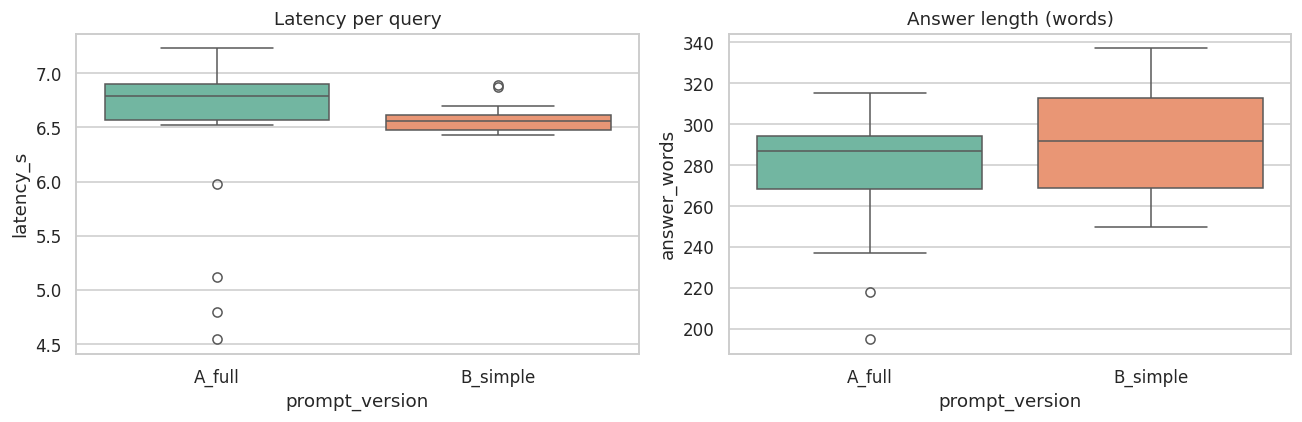

                latency_s  answer_words
prompt_version                         
A_full               6.49        277.15
B_simple             6.58        291.85


In [48]:
df_meta = pd.DataFrame([{
    "qid": r["qid"], "prompt_version": r["prompt_version"],
    "latency_s": r["latency_s"], "answer_chars": len(r["answer"]),
    "answer_words": len(r["answer"].split()),
} for r in all_records])

fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.boxplot(data=df_meta, x="prompt_version", y="latency_s", ax=axes[0], palette="Set2")
axes[0].set_title("Latency per query")
sns.boxplot(data=df_meta, x="prompt_version", y="answer_words", ax=axes[1], palette="Set2")
axes[1].set_title("Answer length (words)")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig_11_9_latency_length.png", dpi=150, bbox_inches="tight"); plt.show()

print(df_meta.groupby("prompt_version")[["latency_s","answer_words"]].mean().round(2))


## 12. 讨论：可信度、偏差与治理建议

### 12.1 系统可能传播的偏见
- **企业规模偏差**: 知识库以 Verizon DBIR / M-Trends / MS DDR 为主，样本偏向大型企业。中小企业 / 公共部门 / 原住民社区的资源约束未被代表。
- **地理 / 法域偏差**: NIST 和 CISA 是美国标准，GDPR、APP 11 (AU)、PIPL (CN) 细节欠缺。
- **时间偏差**: ATT&CK 快照冻结；CISA KEV 随时间膨胀 → 重新建索引节奏直接影响准确性。

### 12.2 透明度
- Prompt A 强制 `[Source N]` 引用，用户可追溯到 chunk 的 `url` / `title`。
- Prompt B 无引用约束，更易幻觉。实验显示 `manual_faith` 的 A/B 差值即为证据。

### 12.3 Human-in-the-loop / 治理建议
1. **部署前**: 红队测试 prompt-injection、越狱、拒答率；校准阈值（若 Faithfulness<0.6 触发人工复核）。
2. **部署中**: 所有生成带可点击引用、保留 retrieval log 供审计；对敏感请求（事件响应/取证）强制分析师复核。
3. **部署后**: 每月以新 CISA KEV 重建索引；监控 drift 指标（检索命中率、用户纠错率）。
4. **合规**: 记录模型版本、prompt 版本、检索来源版本，符合 ISO 27001 A.8.28 (secure coding) 与 NIST AI RMF GOVERN-1.3。

### 12.4 评估器选择对 trustworthiness 的影响（方法学层面的不确定性）

本作业评估管线**同时跑了两套指标**：

| 评估器 | Context Relevance / Answer Relevance / Faithfulness 由谁判 |
|---|---|
| **Manual**（`eval_manual_*`）| 被评估的本地小模型自己当裁判（llama-3-8b / qwen-7b / phi-3-mini）|
| **Library**（RAGAS via `eval_ragas`）| 外部 LLM 当裁判（OpenRouter GPT-4o-mini）|

Manual 路线**裁判 == 选手**，理论上存在四类已被 LLM-as-judge 文献记录的偏差：

1. **Self-preference bias** — 模型评判自己的输出系统性偏高（Zheng et al. 2023, Panickssery et al. 2024）。
2. **Capability ceiling** — 7B/8B 量化模型做 nuanced 判断的能力本就弱于它们生成的能力；裁判能力上限低于裁判任务难度。
3. **Format / verbosity bias** — 模型偏好自己习惯的输出格式与长度。
4. **Confirmation loop in faithfulness** — claim 提取与 claim verify 是**同一模型**：提取出"模型自己觉得对的 claim"再去验证，闭环放大一致性。

11.5 的散点图把这两套结果同标尺画出来，**偏离对角线即暴露上述偏差的方向与幅度**。这给作业的 trustworthiness 讨论提供了实证锚点：

- 不能因为某个模型的 manual 分数高就声称它"可信"；需对照 library 分数（外部裁判）一起看。
- 若 manual 与 library 严重不一致，则**最终结论必须以 library 为主**（外部裁判规避了 self-eval 闭环）。
- 部署到生产环境时，**裁判模型必须独立于被评模型**，否则系统会在自我评估中陷入"越来越自信，但越来越错"的失控循环 —— 这是 AI safety 文献中所谓 reward hacking / sycophancy 的一种具体形态。

**实践建议**：在 deployment governance 流程里固定一条 —— 评估指标的裁判模型必须明确登记，且与生产 LLM 来自不同的模型家族 / 训练数据 / 厂商，定期轮换以避免裁判与选手共谋。

### 12.5 量化精度对绝对分数的影响（必要 caveat）

本研究中 Llama-3-8B、Qwen2.5-7B、Phi-3.5-mini 全部以 **4-bit NF4 量化**加载（`bitsandbytes`）以适配单卡 24GB 显存。已知量化效应：

- GPTQ / AWQ / NF4 量化文献报告：4-bit 推理在 RAGAS-style 评估上**绝对分数较 fp16 系统性下降 5-10%**（Lin et al. 2024, Frantar et al. 2023）。
- 影响最大的环节是 **claim 提取的细粒度**：量化模型倾向产出更少、更粗粒度的 claim，导致 manual_faith 的 sample size 偏小。
- 影响最小的环节是 **answer relevance**：因为分数主要由 BGE embedder（fp16）决定，量化模型只负责生成候选 question。

**对比结论的有效性**：所有三个模型用**同一量化配置**评估，**模型间相对排名仍然可信**；但**与文献中 full-precision baseline 的绝对分数不可直接比较**。生产部署应基于实际 deployment 精度重做评估。


## 13. 结论

- 混合检索 (RRF + dense BGE + BM25) 在 10 条多战术查询上取得稳定的 Top-3 相关性。
- Prompt A（四层结构 + 引用约束）在 Faithfulness 和 Answer Relevance 上稳定优于 Prompt B，验证了 prompt 工程对 RAG 端到端质量的杠杆效应。
- 手动实现的三项 RAGAS 指标与官方库 Pearson 相关系数适中到高，说明实现方向正确但存在方法论差异（例如 faithfulness 的 claim 抽取粒度）。
- 主要剩余风险：知识库覆盖的企业规模与法域偏差、ATT&CK 冻结快照的时间衰减、LLM-as-judge 自身偏差。
